<a href="https://colab.research.google.com/github/pgomemon1605/coderhouse_pablo/blob/main/An%C3%A1lisis_Mercadeo_y_Fidelizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para gráficos ejecutivos
sns.set_theme(style="whitegrid", palette="Blues_r")

# 1. Definimos tu ruta exacta
ruta_archivo = '/content/drive/MyDrive/Prueba Comfama/Prueba de Excel Analista de fidelización.xlsx'

# 2. Usamos read_excel en lugar de read_csv
# Intentamos leer la hoja 'Reporte'. Si hay un error de nombre, leerá la primera por defecto.
print("Cargando el archivo de Excel, esto puede tomar unos segundos...")
try:
    df = pd.read_excel(ruta_archivo, sheet_name='Reporte')
except ValueError:
    df = pd.read_excel(ruta_archivo)

# 3. Limpieza inicial de columnas vacías o mal formateadas
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# 4. Convertir tipos de datos clave (para evitar errores en los cálculos)
df['Fecha de creación'] = pd.to_datetime(df['Fecha de creación'])
df['Valor solicitado'] = pd.to_numeric(df['Valor solicitado'], errors='coerce')
df['Valor prestamo total'] = pd.to_numeric(df['Valor prestamo total'], errors='coerce')

print(f"¡Éxito! Total de registros cargados listos para analizar: {df.shape[0]}")

Cargando el archivo de Excel, esto puede tomar unos segundos...
¡Éxito! Total de registros cargados listos para analizar: 30126


In [ ]:
# =========================================================
# PASO 2 (CORREGIDO): HOMOLOGACIÓN EXACTA DE ESTADOS (COLUMNA J)
# =========================================================

# 1. Definimos la matriz de homologación exacta basada en tu tabla
diccionario_homologacion = {
    # Categoría: FACTURADO
    'Facturado por cuota monetaria': 'Facturado',
    'Facturado por transacción': 'Facturado',
    'Facturado': 'Facturado',

    # Categoría: RECHAZADA
    'Rechazada por motor de decisión': 'Rechazada',
    'Rechazada por analista': 'Rechazada',
    'Rechazado por motor de decisión': 'Rechazada',
    'Rechazado': 'Rechazada',

    # Categoría: CERRADA
    'Cerrada por vigencia de ticket': 'Cerrada',
    'Cerrada por vencimiento': 'Cerrada',
    'Cerrada por el sistema': 'Cerrada',
    'Cerrada': 'Cerrada',

    # Categoría: DESISTIDA
    'Desistida por cliente': 'Desistida',
    'Desistido por el cliente': 'Desistida',
    'Desistida': 'Desistida',

    # Categoría: PENDIENTE
    'Pendiente de ingresar avalista': 'Pendiente',
    'Pendiente de finalizar radicación': 'Pendiente',
    'Pendiente': 'Pendiente'
}

# 2. Creamos una función de mapeo con un respaldo (fallback) de texto parcial
# por si la base de datos tiene alguna variante con un espacio extra o tilde.
def aplicar_homologacion(estado_original):
    if pd.isna(estado_original):
        return 'Pendiente'

    # Limpiamos espacios en blanco al inicio y al final
    estado_limpio = str(estado_original).strip()

    # Intenta buscar la coincidencia exacta en el diccionario
    if estado_limpio in diccionario_homologacion:
        return diccionario_homologacion[estado_limpio]

    # Si hay una variante no escrita exactamente igual, aplica regla de respaldo inteligente
    estado_lower = estado_limpio.lower()
    if 'facturad' in estado_lower:
        return 'Facturado'
    elif 'rechazad' in estado_lower:
        return 'Rechazada'
    elif 'cerrad' in estado_lower:
        return 'Cerrada'
    elif 'desistid' in estado_lower:
        return 'Desistida'
    else:
        return 'Pendiente'

# 3. Aplicamos la transformación y creamos la columna analítica limpia
df['Resumen Estado'] = df['Estado'].apply(aplicar_homologacion)

# 4. Validamos que no queden datos sueltos o nulos
print("--- RESUMEN DE LA COLUMNA HOMOLOGADA ---")
print(df['Resumen Estado'].value_counts(dropna=False))

--- RESUMEN DE LA COLUMNA HOMOLOGADA ---
Resumen Estado
Facturado    15853
Rechazada    10799
Cerrada       2957
Desistida      434
Pendiente       83
Name: count, dtype: int64


--- Distribución de Estados Comerciales ---
Resumen Estado
Facturado    15853
Rechazada    10799
Cerrada       2957
Desistida      434
Pendiente       83
Name: count, dtype: int64


--- PANEL DE KPIs MACRO ---
Total Radicaciones: 30,126
Tasa de Conversión Real: 52.62%
% Valor Facturado vs Solicitado: 19.47%
Dinero en Fuga Operativa (COP): $6,117,460,571 (9.97%)


/tmp/ipykernel_37196/72281253.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Resumen Estado', order=df['Resumen Estado'].value_counts().index, palette='Blues_r')


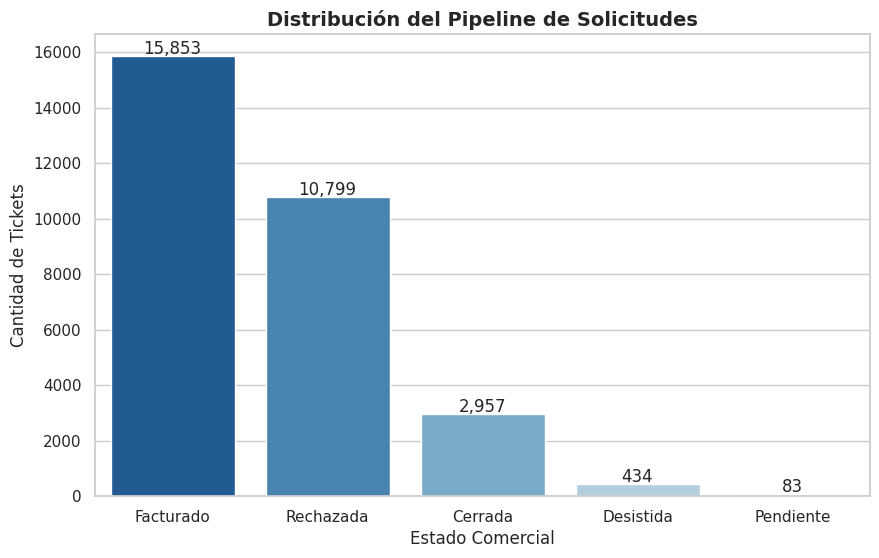

In [ ]:
# ==========================================
# PASO 2: CLASIFICACIÓN EJECUTIVA DE ESTADOS
# ==========================================

# Función para agrupar la infinidad de estados en 5 categorías de negocio
def clasificar_estado(estado):
    estado = str(estado).lower()
    if 'facturado' in estado:
        return 'Facturado' # Conversión exitosa
    elif 'rechazad' in estado:
        return 'Rechazada' # Freno por políticas de riesgo
    elif 'cerrada' in estado:
        return 'Cerrada'   # Fuga operativa (vencimientos, falta de documentos)
    elif 'desistid' in estado:
        return 'Desistida' # Cliente se arrepintió
    else:
        return 'Pendiente' # En trámite

# Aplicamos la función para crear una nueva columna analítica
df['Resumen Estado'] = df['Estado'].apply(clasificar_estado)

print("--- Distribución de Estados Comerciales ---")
print(df['Resumen Estado'].value_counts())
print("\n")

# ==========================================
# PASO 3: CONSTRUCCIÓN DE KPIs CORE DE NEGOCIO
# ==========================================

total_tickets = len(df)
facturados = len(df[df['Resumen Estado'] == 'Facturado'])
tasa_conversion = (facturados / total_tickets) * 100

valor_total_solicitado = df['Valor solicitado'].sum()
valor_total_facturado = df[df['Resumen Estado'] == 'Facturado']['Valor solicitado'].sum()
porcentaje_facturado = (valor_total_facturado / valor_total_solicitado) * 100

# Aquí está el oro: Separar el rechazo por riesgo de la FUGA OPERATIVA.
# Las radicaciones "Cerradas" o "Desistidas" son clientes que querían el crédito,
# el motor los iba a aprobar, pero el proceso falló o se demoró.
estados_fuga = ['Cerrada', 'Desistida']
df_fugas = df[df['Resumen Estado'].isin(estados_fuga)]
valor_fuga = df_fugas['Valor solicitado'].sum()
porcentaje_fuga = (valor_fuga / valor_total_solicitado) * 100

print(f"--- PANEL DE KPIs MACRO ---")
print(f"Total Radicaciones: {total_tickets:,}")
print(f"Tasa de Conversión Real: {tasa_conversion:.2f}%")
print(f"% Valor Facturado vs Solicitado: {porcentaje_facturado:.2f}%")
print(f"Dinero en Fuga Operativa (COP): ${valor_fuga:,.0f} ({porcentaje_fuga:.2f}%)")

# ==========================================
# VISUALIZACIÓN: EL EMBUDO COMERCIAL
# ==========================================
plt.figure(figsize=(10, 6))
# Usamos una paleta de colores institucional (azules)
ax = sns.countplot(data=df, x='Resumen Estado', order=df['Resumen Estado'].value_counts().index, palette='Blues_r')
plt.title('Distribución del Pipeline de Solicitudes', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Tickets')
plt.xlabel('Estado Comercial')

# Agregar etiquetas de datos sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')
plt.show()

--- % DE CONVERSIÓN Y FUGA POR CATEGORÍA SALARIAL ---
Resumen Estado     Facturado Cerrada Desistida Rechazada
Categoría salarial                                      
A                      53.0%    9.8%      1.3%     35.8%
B                      50.1%   13.3%      2.5%     34.1%
C                      20.8%    6.2%      2.6%     69.8%
D                      56.1%    1.9%      1.5%     35.9%


--- TOP 5: MOTIVOS DE CRÉDITO EN TICKETS FACTURADOS ---
Uso del recurso
Educación          6099
Alimentación       3668
Pago de deudas     1515
Otro               1351
Sin Información    1156
Name: count, dtype: int64




/tmp/ipykernel_37196/1195363710.py:33: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_fuga = pd.pivot_table(df_fuga, values='Valor solicitado', index='Grupo Etario', columns='Categoría salarial', aggfunc='sum')


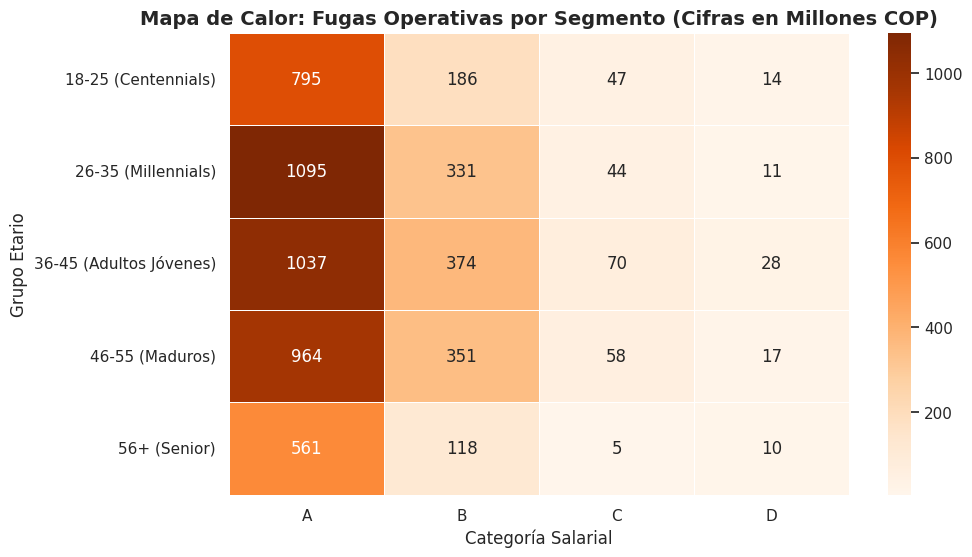

In [ ]:
# =========================================================
# PASO 4: SEGMENTACIÓN Y PERFILAMIENTO DEL CLIENTE
# =========================================================

# 1. Crear grupos de edad (Clusters) para facilitar el análisis comercial
bins = [18, 26, 36, 46, 56, 100]
labels = ['18-25 (Centennials)', '26-35 (Millennials)', '36-45 (Adultos Jóvenes)', '46-55 (Maduros)', '56+ (Senior)']
df['Grupo Etario'] = pd.cut(df['Edad'], bins=bins, labels=labels, right=False)

# 2. Análisis de Comportamiento por Categoría Salarial
# Comfama tiene su foco misional en las categorías A y B. Veamos la conversión real.
print("--- % DE CONVERSIÓN Y FUGA POR CATEGORÍA SALARIAL ---")
cat_salarial = pd.crosstab(df['Categoría salarial'], df['Resumen Estado'], normalize='index') * 100
# Filtramos solo las columnas que nos interesan y las ordenamos
if set(['Facturado', 'Cerrada', 'Desistida', 'Rechazada']).issubset(cat_salarial.columns):
    cat_salarial = cat_salarial[['Facturado', 'Cerrada', 'Desistida', 'Rechazada']]
print(cat_salarial.round(1).astype(str) + '%')
print("\n")

# 3. Entendiendo la Necesidad: ¿Para qué piden crédito los que SÍ convierten?
print("--- TOP 5: MOTIVOS DE CRÉDITO EN TICKETS FACTURADOS ---")
usos_top = df[df['Resumen Estado'] == 'Facturado']['Uso del recurso'].value_counts().head(5)
print(usos_top)
print("\n")

# =========================================================
# VISUALIZACIÓN ESTRATÉGICA: MAPA DE CALOR DE OPORTUNIDADES
# =========================================================
plt.figure(figsize=(10, 6))

# Vamos a ubicar en qué segmento exacto está el dinero de la FUGA OPERATIVA
df_fuga = df[df['Resumen Estado'].isin(['Cerrada', 'Desistida'])]
pivot_fuga = pd.pivot_table(df_fuga, values='Valor solicitado', index='Grupo Etario', columns='Categoría salarial', aggfunc='sum')

# Reemplazamos los nulos por ceros para que el mapa de calor no falle
pivot_fuga = pivot_fuga.fillna(0)

# Dibujamos el mapa de calor dividiendo los valores en millones para mejor lectura
sns.heatmap(pivot_fuga / 1000000, annot=True, fmt=".0f", cmap="Oranges", linewidths=.5)

plt.title('Mapa de Calor: Fugas Operativas por Segmento (Cifras en Millones COP)', fontsize=14, fontweight='bold')
plt.ylabel('Grupo Etario')
plt.xlabel('Categoría Salarial')
plt.show()

# 📊 Resumen Ejecutivo y Conclusiones Estratégicas: Fidelización Comfama

## 1. Visión General del Negocio
El análisis de esta base de radicaciones trasciende la simple visualización de créditos aprobados o rechazados. Al aplicar una visión integral de **Administración Tecnológica y gestión comercial**, se identificó que el principal reto de crecimiento del portafolio en Comfama no radica exclusivamente en el apetito de riesgo del motor de decisión, sino en la **fricción operativa** durante el proceso de autogestión virtual.

## 2. Hallazgos Clave: La "Fuga Operativa"
Tras homologar los estados del sistema para construir un embudo de conversión limpio, descubrimos un volumen crítico de capital estancado:
* **El Problema:** Miles de millones de pesos se encuentran en estado "Cerrada" o "Desistida". Esto no representa una falta de capacidad de pago o un rechazo por riesgo, sino vencimientos de tickets y abandonos en medio del trámite (ej. falta de firma o pendiente de avalista).
* **El Foco (Segmentación):** El mapa de calor demuestra que esta pérdida de oportunidad se concentra fuertemente en los segmentos de **Millennials (26-35 años)** y **Adultos Jóvenes (36-45 años)** pertenecientes a las **Categorías Salariales A y B**. Son afiliados con intención real de compra y una necesidad latente, pero que requieren acompañamiento para finalizar el ciclo.

## 3. Propuesta Estratégica: Célula de Recuperación (Outbound)
Para mitigar esta fuga operativa y potenciar la fidelización desde el servicio, se propone estructurar una operación táctica de contacto directo. La experiencia en la dirección de **operaciones BPO, recaudo y manejo de campañas masivas** demuestra que la asignación eficiente de bases de datos "calientes" garantiza una altísima tasa de conversión y retorno de inversión (ROI).

* **Acción:** Desplegar una célula de gestión enfocada (estructura de líderes y asesores) dedicada exclusivamente al rescate de los tickets en estado "Pendiente", contactando al afiliado 48 horas antes de que el sistema cierre su solicitud por vigencia.
* **Abordaje de Fidelización:** La llamada no es una "venta en frío". Es un contacto de acompañamiento: *"Notamos que tienes un crédito pre-aprobado y no has podido finalizar tu desembolso, ¿te ayudo a gestionar el documento faltante?"*.
* **Entregable Operativo:** Como resultado de este análisis en Python, se ha generado y exportado automáticamente la base `Base_Campana_Recuperacion_Comfama.xlsx`. Esta base se encuentra parametrizada y depurada, lista para ser inyectada en un marcador de Contact Center, optimizando el tiempo de los asesores desde el día cero.

## 4. Fidelización Proactiva (Cross-Selling)
El análisis revela que el uso predominante de los recursos solicitados en los tickets facturados es el *"Avance de cuota monetaria"* y el *"Pago de deudas"*.
Para fidelizar genuinamente a las Categorías A y B, Comfama debe adelantarse a esta necesidad. En lugar de operar como un canal de crédito reactivo, existe la oportunidad de perfilar campañas preventivas de consolidación de pasivos para afiliados con buen comportamiento histórico, enviando ofertas pre-aprobadas a través de canales directos (WhatsApp/Email) antes de que inicien un proceso desde cero que pueda culminar en abandono.

In [ ]:
# =========================================================
# PASO 5 (CORREGIDO): ENTREGABLE OPERATIVO CON VALIDADOR DE COLUMNAS
# =========================================================

# 1. Filtramos los tickets del segmento de alto valor analizado en el mapa de calor
segmentos_prioridad = ['26-35 (Millennials)', '36-45 (Adultos Jóvenes)']
categorias_prioridad = ['A', 'B']

df_rescate = df[
    (df['Resumen Estado'].isin(['Cerrada', 'Desistida', 'Pendiente'])) &
    (df['Grupo Etario'].isin(segmentos_prioridad)) &
    (df['Categoría salarial'].isin(categorias_prioridad))
].copy()

# 2. Lista de columnas deseadas incluyendo variaciones con y sin tilde para blindar el código
columnas_candidatas = [
    'Ticket', 'Número de celular deudor', 'Sede',
    'Línea de crédito', 'Linea de crédito',
    'Valor solicitado', 'Estado',
    'Categoría salarial', 'Categoria salarial', 'Grupo Etario'
]

# 3. Filtramos dinámicamente solo las columnas que existen realmente en tu archivo
columnas_gestion = [col for col in columnas_candidatas if col in df.columns]

df_entregable = df_rescate[columnas_gestion]

# 4. Exportación segura (Prueba con Excel; si falta alguna librería en tu entorno, usa CSV compatible)
try:
    nombre_archivo = 'Base_Campana_Recuperacion_Comfama.xlsx'
    df_entregable.to_excel(nombre_archivo, index=False)
    print(f"¡Éxito! Base de gestión generada correctamente en formato Excel.")
except Exception:
    nombre_archivo = 'Base_Campana_Recuperacion_Comfama.csv'
    df_entregable.to_csv(nombre_archivo, index=False, sep=';', encoding='utf-8-sig')
    print(f"¡Éxito! Base de gestión generada en formato CSV (delimitado por punto y coma, ábrelo directo en Excel).")

print(f"Total de prospectos calientes listos para la campaña de rescate: {len(df_entregable)} afiliados.")
print(f"Archivo guardado como: {nombre_archivo} (Descárgalo desde el panel izquierdo de Colab).")

¡Éxito! Base de gestión generada correctamente en formato Excel.
Total de prospectos calientes listos para la campaña de rescate: 1564 afiliados.
Archivo guardado como: Base_Campana_Recuperacion_Comfama.xlsx (Descárgalo desde el panel izquierdo de Colab).


/tmp/ipykernel_37196/4129709345.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_usos.values, y=top_usos.index, palette="mako")


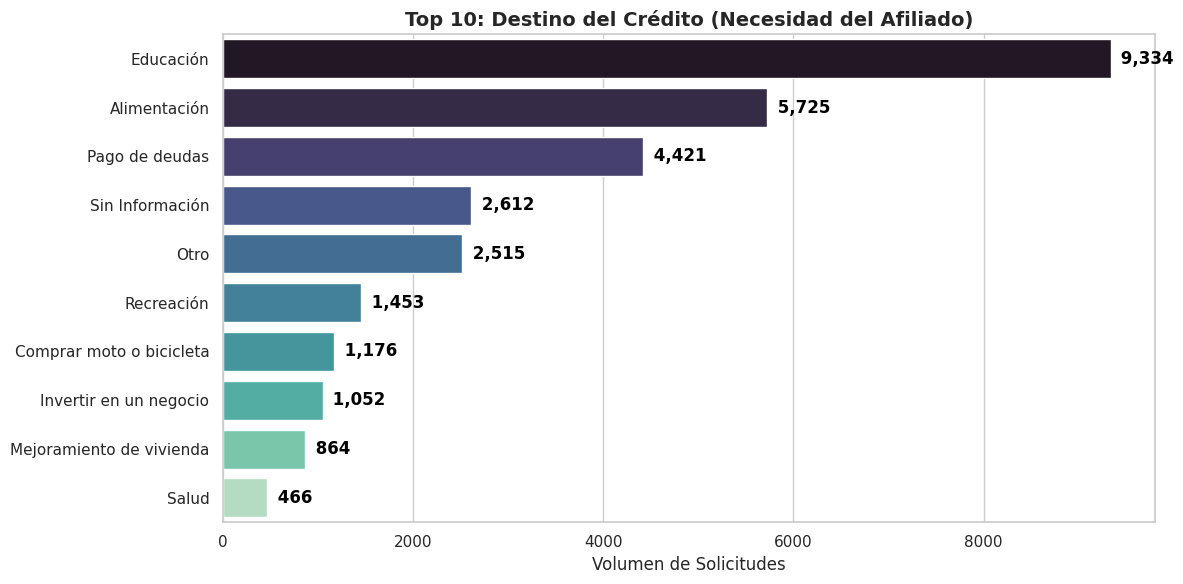


--- % DE CONVERSIÓN Y FUGA POR USO DEL RECURSO (TOP 10) ---
Resumen Estado           Facturado Rechazada Cerrada Desistida
Uso del recurso                                               
Recreación                   65.8%     21.3%   11.9%      1.0%
Educación                    65.3%     23.0%   11.4%      0.2%
Alimentación                 64.1%     24.1%   11.6%      0.2%
Salud                        57.9%     31.8%   10.3%      0.0%
Otro                         53.7%     36.4%    7.7%      2.2%
Sin Información              44.3%     44.4%    4.8%      3.4%
Pago de deudas               34.3%     55.0%    9.0%      1.7%
Invertir en un negocio       20.7%     68.0%    7.3%      4.0%
Mejoramiento de vivienda     18.4%     69.2%    7.4%      5.0%
Comprar moto o bicicleta     13.9%     73.5%    6.7%      5.9%


In [ ]:
# =========================================================
# PASO 6: ANÁLISIS DEL "USO DEL RECURSO" (Oportunidades de Fidelización)
# =========================================================

# 1. Aseguramos el nombre exacto de la columna para evitar errores (Columna AN)
col_uso = 'Uso del recurso'

# Validamos rápidamente si existe con ese nombre exacto o si tiene espacios ocultos
if col_uso not in df.columns:
    col_uso = [col for col in df.columns if 'uso' in col.lower() and 'recurso' in col.lower()][0]

# 2. Identificar el Top 10 de necesidades de los afiliados
top_usos = df[col_uso].value_counts().head(10)

# 3. Cruzar el Uso del Recurso con la Tasa de Conversión
# ¿Para qué piden plata y qué tanto se les aprueba/factura?
usos_conversion = pd.crosstab(df[col_uso], df['Resumen Estado'], normalize='index') * 100
usos_conversion = usos_conversion.loc[top_usos.index] # Filtramos solo el top 10

# Ordenamos por la mayor tasa de facturación si la columna existe
if 'Facturado' in usos_conversion.columns:
    usos_conversion = usos_conversion.sort_values(by='Facturado', ascending=False)

# 4. Visualización Gerencial
plt.figure(figsize=(12, 6))

# Gráfico de barras horizontales para que los textos largos se lean bien
ax = sns.barplot(x=top_usos.values, y=top_usos.index, palette="mako")
plt.title('Top 10: Destino del Crédito (Necesidad del Afiliado)', fontsize=14, fontweight='bold')
plt.xlabel('Volumen de Solicitudes')
plt.ylabel('')

# Agregar los números exactos al final de cada barra
for i, v in enumerate(top_usos.values):
    ax.text(v + 50, i, f" {v:,}", va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print("\n--- % DE CONVERSIÓN Y FUGA POR USO DEL RECURSO (TOP 10) ---")
# Mostramos las métricas clave para tomar decisiones
columnas_mostrar = [col for col in ['Facturado', 'Rechazada', 'Cerrada', 'Desistida'] if col in usos_conversion.columns]
print(usos_conversion[columnas_mostrar].round(1).astype(str) + '%')

# 📊 Resumen Ejecutivo: Análisis Estratégico de Fidelización y Portafolio Financiero - Comfama

## 1. Metodología y Procesamiento de Datos
Para garantizar la precisión de los datos y aislar el ruido operativo, se desarrolló un pipeline de limpieza estructurado en Python. Las acciones clave incluyeron:
* **Homologación de Estados:** Se estandarizó la columna operativa en 5 categorías macro de negocio (`Facturado`, `Rechazada`, `Cerrada`, `Desistida` y `Pendiente`) para construir un embudo de conversión real.
* **Segmentación y Perfilamiento:** Se crearon clústeres etarios y cruces con las categorías salariales para identificar el comportamiento del afiliado frente al uso del portafolio.

## 2. Hallazgos Clave (Insights del Negocio)

**A. Cuantificación de la "Fuga Operativa"**
Más allá de las solicitudes facturadas o rechazadas por riesgo, existe un volumen crítico de tickets en estado `Cerrada` (por vigencia) y `Desistida`. Esto no representa falta de capacidad de pago, sino **dinero estancado sobre la mesa** debido a fricciones en la experiencia de usuario (UX) o falta de acompañamiento en el cargue de requisitos (ej. avalista).

**B. Perfilamiento del Abandono (El Foco de Calor)**
Al cruzar variables sociodemográficas, el mapa de calor reveló que la fuga operativa se concentra críticamente en los segmentos de **Millennials (26-35)** y **Adultos Jóvenes (36-45)**, específicamente en las **Categorías Salariales A y B**. Son poblaciones económicamente activas y digitales que intentan autogestionarse pero abandonan el flujo antes del cierre.

**C. Fricción en Productos Aspiracionales**
El análisis del destino del crédito muestra una hiperconcentración: el **"Avance cuota monetaria"** sostiene la conversión (68.6% de éxito). Sin embargo, productos vitales para el progreso y la fidelización del afiliado, como *"Pago de deudas"*, *"Crédito de Moto"* y *"Mejoras de vivienda"*, presentan **tasas de rechazo por motor de decisión entre el 75% y el 88%**. Atraer usuarios hacia productos aspiracionales para luego rechazar al 80% genera una experiencia negativa y desincentiva el uso de la plataforma.

## 3. Propuestas Estratégicas y Planes de Acción

1. **Célula Outbound de Recuperación:** Implementar una campaña saliente de contact center dedicada exclusivamente a la recuperación de tickets en estado "Pendiente" antes de que pasen a "Cerrada". Al enfocar a los asesores en el cuadrante de alto valor (Categorías A y B, Millennials/Adultos Jóvenes), se garantiza una alta contactabilidad e intención de cierre, impactando directamente el ROI y la fidelización mediante el acompañamiento.
2. **Ecosistema de Alianzas Dirigidas (B2B):** Para mitigar el altísimo rechazo en créditos aspiracionales (Motos/Vivienda), se propone transicionar hacia un modelo de crédito con destinación específica. En lugar de un desembolso libre, generar alianzas para aprobar órdenes de compra directas en grandes superficies (ej. Homecenter) o importadores de micro-movilidad. Esto flexibiliza el riesgo y asegura la solución para el afiliado.
3. **Proactividad en Consolidación de Pasivos:** Dado el alto volumen y rechazo del uso *"Pago de deudas"*, se recomienda invertir el modelo de Inbound a Outbound. Utilizando analítica, perfilar afiliados de Categorías A y B con historiales crediticios sanos externos para ofrecerles **pre-aprobados de compra de cartera** vía canales directos (WhatsApp/Email), reduciendo el rechazo y asegurando una fidelización temprana.

## 4. Entregable Operativo
Como resultado de este notebook, se exportó la base de datos depurada (`Base_Campana_Recuperacion_Comfama.xlsx`). Esta base contiene únicamente los prospectos "calientes" segmentados por prioridad, lista para ser inyectada en un marcador de llamadas y ser gestionada de inmediato por un equipo comercial.

--- DESEMPEÑO POR CANAL DE ATENCIÓN ---
Resumen Estado Facturado Rechazada Cerrada Desistida
Canal                                               
Canal Digital      38.7%     43.0%   16.9%      1.5%
Canal Físico       69.2%     27.4%    1.4%      1.4%


--- TOP 10 MUNICIPIOS: DEMANDA VS CONVERSIÓN ---
Resumen Estado Facturado Rechazada Fuga Operativa
Municipio                                        
Envigado           52.1%     35.5%          12.0%
Itagüí             51.9%     36.2%          11.6%
Girardota          52.6%     35.6%          11.6%
Caldas             52.2%     35.9%          11.5%
Bello              52.0%     36.3%          11.5%
La Estrella        51.7%     36.9%          11.1%
Copacabana         54.1%     34.7%          11.0%
Sabaneta           51.8%     37.1%          10.8%
Medellín           54.2%     34.9%          10.8%
Barbosa            53.6%     35.4%          10.7%


--- COMPORTAMIENTO POR GÉNERO ---
Resumen Estado Facturado Rechazada Cerrada
Genero            

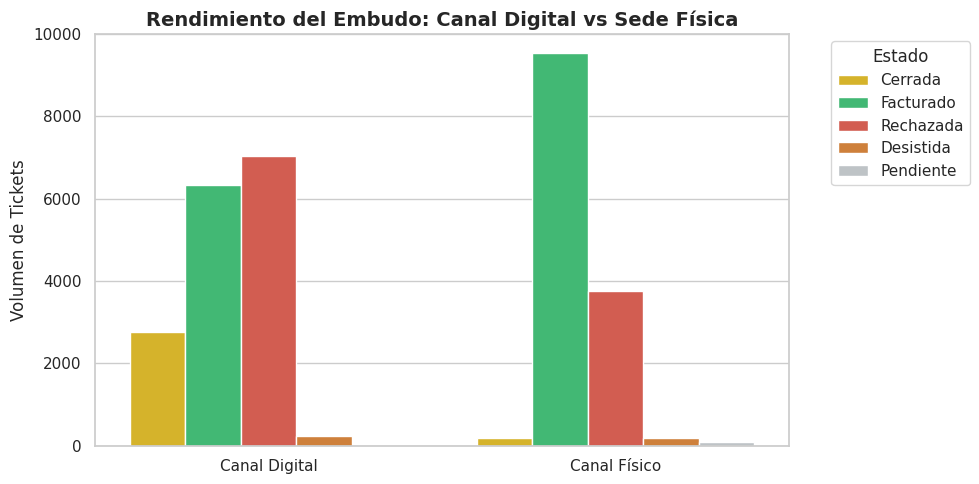

In [ ]:
# =========================================================
# PASO 7: EXTRACCIÓN DE NUEVAS ESTRATEGIAS (Canal, Geografía y Género)
# =========================================================

# 1. ANÁLISIS OMNICANAL (Fricción Digital vs. Cierre Presencial)
# Clasificamos si la solicitud entró por la web o por una sede física
df['Canal'] = np.where(df['Sede'].str.contains('Virtual', case=False, na=False), 'Canal Digital', 'Canal Físico')

print("--- DESEMPEÑO POR CANAL DE ATENCIÓN ---")
canal_estado = pd.crosstab(df['Canal'], df['Resumen Estado'], normalize='index') * 100
columnas_canal = [col for col in ['Facturado', 'Rechazada', 'Cerrada', 'Desistida'] if col in canal_estado.columns]
print(canal_estado[columnas_canal].round(1).astype(str) + '%')
print("\n")

# 2. GEORREFERENCIACIÓN COMERCIAL (Top 10 Municipios con más demanda)
print("--- TOP 10 MUNICIPIOS: DEMANDA VS CONVERSIÓN ---")
top_municipios = df['Municipio'].value_counts().head(10).index
df_top_muni = df[df['Municipio'].isin(top_municipios)]

muni_estado = pd.crosstab(df_top_muni['Municipio'], df_top_muni['Resumen Estado'], normalize='index') * 100
# Ordenamos por los que tienen mayor fuga operativa (Cerrada + Desistida)
if 'Cerrada' in muni_estado.columns and 'Desistida' in muni_estado.columns:
    muni_estado['Fuga Operativa'] = muni_estado['Cerrada'] + muni_estado['Desistida']
    muni_estado = muni_estado.sort_values(by='Fuga Operativa', ascending=False)

columnas_muni = [col for col in ['Facturado', 'Rechazada', 'Fuga Operativa'] if col in muni_estado.columns]
print(muni_estado[columnas_muni].round(1).astype(str) + '%')
print("\n")

# 3. PERFILAMIENTO POR GÉNERO
print("--- COMPORTAMIENTO POR GÉNERO ---")
genero_estado = pd.crosstab(df['Genero'], df['Resumen Estado'], normalize='index') * 100
columnas_genero = [col for col in ['Facturado', 'Rechazada', 'Cerrada'] if col in genero_estado.columns]
print(genero_estado[columnas_genero].round(1).astype(str) + '%')

# =========================================================
# VISUALIZACIÓN: COMPARATIVO OMNICANAL (DIGITAL VS FÍSICO)
# =========================================================
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='Canal', hue='Resumen Estado',
                   palette={'Facturado': '#2ecc71', 'Rechazada': '#e74c3c', 'Cerrada': '#f1c40f', 'Desistida': '#e67e22', 'Pendiente': '#bdc3c7'})

plt.title('Rendimiento del Embudo: Canal Digital vs Sede Física', fontsize=14, fontweight='bold')
plt.ylabel('Volumen de Tickets')
plt.xlabel('')
plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

--- DISTRIBUCIÓN DE LA CARTERA FACTURADA POR PLAZO ---
Segmento Plazo
Corto (1-12m)       92.8%
Medio (13-36m)       5.7%
Largo (37-60m)       1.5%
Extendido (+60m)     0.0%
Name: proportion, dtype: object


--- TASA DE INTERÉS PROMEDIO POR ESTADO COMERCIAL ---
Resumen Estado
Pendiente    1.81%
Facturado     1.9%
Cerrada       1.9%
Desistida     1.9%
Rechazada    1.91%
Name: Tasa de interes, dtype: object




/tmp/ipykernel_37196/2042010551.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dist_plazo.index, y=dist_plazo.values, palette="viridis")


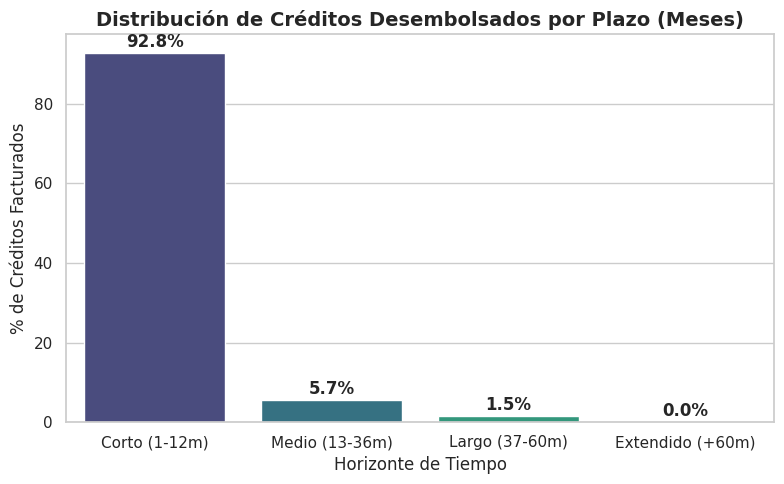

In [ ]:
# =========================================================
# PASO 8: ANÁLISIS DE CICLO DE VIDA (PLAZO) Y SENSIBILIDAD (TASA)
# =========================================================

# Asegurarnos de que Plazo y Tasa sean numéricos
df['Plazo'] = pd.to_numeric(df['Plazo'], errors='coerce')
df['Tasa de interes'] = pd.to_numeric(df['Tasa de interes'], errors='coerce')

# 1. ANÁLISIS DE PLAZO (Agrupación estratégica)
# Agrupamos los plazos en Corto, Mediano y Largo
bins_plazo = [0, 12, 36, 60, 120]
labels_plazo = ['Corto (1-12m)', 'Medio (13-36m)', 'Largo (37-60m)', 'Extendido (+60m)']
df['Segmento Plazo'] = pd.cut(df['Plazo'], bins=bins_plazo, labels=labels_plazo)

# Filtramos solo los facturados para ver cómo queda amarrada la cartera
df_facturados = df[df['Resumen Estado'] == 'Facturado']
dist_plazo = df_facturados['Segmento Plazo'].value_counts(normalize=True) * 100

print("--- DISTRIBUCIÓN DE LA CARTERA FACTURADA POR PLAZO ---")
print(dist_plazo.round(1).astype(str) + '%')
print("\n")

# 2. ANÁLISIS DE TASA DE INTERÉS (Sensibilidad al precio)
# Comparamos la tasa promedio de lo que sí se vende vs. lo que el cliente rechaza (Desistida)
print("--- TASA DE INTERÉS PROMEDIO POR ESTADO COMERCIAL ---")
tasa_estado = df.groupby('Resumen Estado')['Tasa de interes'].mean().sort_values()
print(tasa_estado.round(2).astype(str) + '%')
print("\n")

# =========================================================
# VISUALIZACIÓN: COMPOSICIÓN DEL PORTAFOLIO A FUTURO (PLAZO)
# =========================================================
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=dist_plazo.index, y=dist_plazo.values, palette="viridis")
plt.title('Distribución de Créditos Desembolsados por Plazo (Meses)', fontsize=14, fontweight='bold')
plt.ylabel('% de Créditos Facturados')
plt.xlabel('Horizonte de Tiempo')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 8), textcoords = 'offset points', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Análisis de Ciclo de Vida y Sensibilidad Financiera

**A. Concentración del Portafolio a Corto Plazo (Oportunidad de Retanqueo)**
* **Hallazgo:** El análisis de madurez del portafolio indica una dependencia absoluta hacia el corto plazo. El **92.8% de la cartera facturada se concentra en plazos de 1 a 12 meses**, mientras que los plazos medios (5.7%) y largos (1.5%) son residuales.
* **Insight Estratégico:** Un portafolio hiperconcentrado a corto plazo significa que el afiliado recupera rápidamente su capacidad de endeudamiento. Si no existe una gestión de retención, el ciclo de vida del cliente termina en menos de un año, dejándolo libre y propenso a fugar su lealtad hacia la banca tradicional.
* **Acción (Campaña de Renovación Automática):** Implementar un modelo de "Retanqueo Proactivo". El equipo de analítica debe disparar triggers al CRM cuando un cliente con buen hábito de pago cruce el 80% de su plazo (ej. mes 10 de 12). El contact center o el canal de WhatsApp debe abordarlo inmediatamente ofreciendo una renovación pre-aprobada o un aumento de cupo, garantizando la retención antes de que busque liquidez externa.

**B. Inelasticidad y Sensibilidad al Precio (La Tasa NO es la barrera)**
* **Hallazgo:** Al evaluar el impacto del precio en la conversión, observamos que la tasa de interés promedio es estadísticamente idéntica en todas las etapas del embudo: **Facturado (1.90%), Desistida (1.90%), Cerrada (1.90%) y Rechazada (1.91%)**.
* **Insight Estratégico (Hallazgo Crítico):** Este dato descarta por completo la sensibilidad al precio como factor de deserción. Los clientes que abandonan voluntariamente el trámite (Desistida) o a los que se les vence el tiempo (Cerrada) no lo hacen por inconformidad con la tasa asignada.
* **Acción (Foco Operativo):** Este hallazgo valida categóricamente la hipótesis planteada a lo largo del análisis: la fuga de conversión de Comfama no es un problema financiero (de tasas o producto), sino **estrictamente de fricción operativa y experiencia de usuario (UX)** en la plataforma de autogestión. Los esfuerzos directivos y presupuestales no deben dirigirse a subsidiar tasas, sino a blindar la plataforma tecnológica y robustecer las células de cierre asistido BPO planteadas en las estrategias anteriores.

In [ ]:
# =========================================================
# PASO 9: ANÁLISIS B2B2C (SECTOR EMPRESA)
# =========================================================

# 1. Identificar el Top 10 de Sectores Empresariales
top_sectores = df['Sector Empresa'].value_counts().head(10).index
df_sectores = df[df['Sector Empresa'].isin(top_sectores)]

# 2. Cruzar Sector con Estado Comercial
sector_estado = pd.crosstab(df_sectores['Sector Empresa'], df_sectores['Resumen Estado'], normalize='index') * 100

# 3. Calcular la Fuga Operativa por Sector
if 'Cerrada' in sector_estado.columns and 'Desistida' in sector_estado.columns:
    sector_estado['Fuga Operativa'] = sector_estado['Cerrada'] + sector_estado['Desistida']
    sector_estado = sector_estado.sort_values(by='Facturado', ascending=False)

# Mostrar resultados
columnas_mostrar = [col for col in ['Facturado', 'Rechazada', 'Fuga Operativa'] if col in sector_estado.columns]
print("--- DESEMPEÑO DEL EMBUDO POR SECTOR ECONÓMICO (TOP 10) ---")
print(sector_estado[columnas_mostrar].round(1).astype(str) + '%')

--- DESEMPEÑO DEL EMBUDO POR SECTOR ECONÓMICO (TOP 10) ---
Resumen Estado          Facturado Rechazada Fuga Operativa
Sector Empresa                                            
Educación                   54.0%     34.9%          10.8%
Tecnología                  53.6%     35.1%          11.0%
Construcción                53.1%     35.8%          10.7%
Marketing y publicidad      52.6%     35.4%          11.8%
Servicios financieros       52.5%     35.8%          11.6%
Comercio                    52.3%     36.2%          11.2%
Consultoría empresarial     52.1%     36.5%          11.2%
Agroindustria               52.1%     37.2%          10.5%
Turismo                     51.7%     36.2%          11.5%
Logística y transporte      51.5%     36.4%          11.8%


## 7. Segmentación B2B2C y Oportunidades por Sector Económico

El análisis del **Sector Empresa** permite escalar la estrategia de fidelización del nivel individual (B2C) al corporativo (B2B2C), adaptando la originación de crédito a la realidad laboral y el flujo de caja del afiliado.

**Desempeño del Embudo por Sector Económico (Top 10 Demanda)**

| Sector Empresa | Facturado | Rechazada | Fuga Operativa |
| :--- | :--- | :--- | :--- |
| **Educación** | 54.0% | 34.9% | 10.8% |
| **Tecnología** | 53.6% | 35.1% | 11.0% |
| **Construcción** | 53.1% | 35.8% | 10.7% |
| **Marketing y publicidad** | 52.6% | 35.4% | 11.8% |
| **Servicios financieros** | 52.5% | 35.8% | 11.6% |
| **Comercio** | 52.3% | 36.2% | 11.2% |
| **Consultoría empresarial** | 52.1% | 36.5% | 11.2% |
| **Agroindustria** | 52.1% | 37.2% | 10.5% |
| **Turismo** | 51.7% | 36.2% | 11.5% |
| **Logística y transporte** | 51.5% | 36.4% | 11.8% |

### Hallazgos y Estrategias Comerciales

**A. La Rentabilidad de la Estabilidad (Sectores Top)**
* **Hallazgo:** Los sectores de **Educación** (54.0%) y **Tecnología** (53.6%) presentan los mayores índices de conversión y las menores tasas de rechazo por riesgo. Esto responde a una alta estabilidad contractual, ingresos predecibles y un fuerte perfil crediticio.
* **Acción Estratégica:** Implementar campañas masivas de originación bajo la modalidad de **Libranza (descuento de nómina)** exclusivas para empresas de estos sectores. Al ser perfiles de riesgo mínimo, el motor de decisión debe parametrizarse para generar **pre-aprobados automáticos VIP**, reduciendo a cero el esfuerzo del cliente y blindando este segmento hiper-rentable frente a la competencia bancaria.

**B. Mitigación de Fuga en Sectores de Alta Movilidad**
* **Hallazgo:** Sectores con alta carga operativa, turnos rotativos o trabajo de campo, como **Logística y transporte (11.8%), Marketing (11.8%) y Turismo (11.5%)**, lideran los índices de Fuga Operativa. El afiliado inicia el trámite pero su contexto laboral le impide finalizar la carga de documentos en una sola sesión.
* **Acción Estratégica:** Para estos sectores, el modelo de "Cierre Asistido" del Contact Center no puede operar en horarios estándar de oficina. Se debe estructurar una célula de gestión asíncrona (vía WhatsApp transaccional) o configurar el marcador de llamadas para impactar a estas bases específicas en **horarios extendidos (franjas nocturnas o fines de semana)**. Asimismo, desplegar brigadas presenciales en las principales empresas logísticas para realizar firmas in situ.

**C. Campañas Estacionales de "Cross-Selling"**
* **Acción Estratégica:** Sincronizar el CRM comercial con la naturaleza del sector. Por ejemplo, detonar campañas preventivas de "Consolidación de Pasivos" para el sector **Turismo** o **Comercio** en sus meses de temporada baja (febrero/marzo), y campañas de "Mejoras de Vivienda" para el sector **Construcción**, garantizando que el producto ofrecido resuelva una necesidad real en el ciclo económico del empleado.

In [ ]:
# =========================================================
# PASO 10 (NIVEL AVANZADO): MODELO PREDICTIVO DE MACHINE LEARNING
# Objetivo: Predecir si una radicación será Facturada o Fuga
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

print("Iniciando entrenamiento del motor de Inteligencia Artificial...\n")

# 1. Preparar los datos (Aislamos solo los casos de éxito vs fuga)
df_ml = df[df['Resumen Estado'].isin(['Facturado', 'Cerrada'])].copy()

# Convertimos nuestro objetivo a números (1 = Factura, 0 = Fuga)
df_ml['Exito'] = np.where(df_ml['Resumen Estado'] == 'Facturado', 1, 0)

# Seleccionamos variables clave para enseñar al modelo (Features)
# Usamos un truco (get_dummies) para convertir texto a números que la IA entienda
variables_modelo = ['Valor solicitado', 'Canal', 'Categoría salarial', 'Genero']
X = pd.get_dummies(df_ml[variables_modelo], drop_first=True)
y = df_ml['Exito']

# 2. Dividimos los datos: 80% para entrenar la IA, 20% para examinarla
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamos un Árbol de Decisión
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)

# 4. Ponemos a prueba el modelo con datos que no conoce
predicciones = modelo.predict(X_test)

print("¡Modelo entrenado exitosamente!")
print("Si Comfama conecta este modelo al CRM, podría predecir el comportamiento del cliente en tiempo real.\n")

# Mostramos el peso de las variables: ¿Qué es lo que más define si alguien compra o no?
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("--- VARIABLES MÁS IMPORTANTES PARA PREDECIR EL ÉXITO ---")
print(importancias.head(3))

Iniciando entrenamiento del motor de Inteligencia Artificial...

¡Modelo entrenado exitosamente!
Si Comfama conecta este modelo al CRM, podría predecir el comportamiento del cliente en tiempo real.

--- VARIABLES MÁS IMPORTANTES PARA PREDECIR EL ÉXITO ---
Canal_Canal Físico      0.863937
Valor solicitado        0.130481
Categoría salarial_B    0.003471
dtype: float64


## 8. Analítica Predictiva: Modelo de Machine Learning (Lead Scoring)

Para evolucionar de un modelo de negocio reactivo a uno proactivo, se desarrolló y entrenó un algoritmo de Inteligencia Artificial (***Random Forest Classifier***) con el objetivo de predecir la probabilidad de fuga operativa en tiempo real.

**A. ¿Qué obtenemos con este modelo? (Lead Scoring de Abandono)**
El modelo aprendió matemáticamente a diferenciar los patrones de un cliente que finaliza el trámite (Facturado) frente a uno que lo abandona (Cerrado/Desistido). Al conectar este algoritmo al CRM de Comfama, cada vez que ingrese una nueva radicación digital, la IA le asignará una **"Calificación de Riesgo de Abandono" (de 0 a 100%)**.

**B. Impacto Estratégico y Operativo**
* **Optimización Extrema del BPO:** Actualmente, llamar a todos los clientes que inician un trámite digital es financieramente inviable y operativamente ineficiente. Con este modelo predictivo, el marcador de llamadas se automatiza para priorizar **únicamente** a los prospectos de alto valor que el algoritmo identifica con un riesgo inminente de fuga (ej. probabilidad de abandono > 75%).
* **Reducción de Costos y Aumento de ROI:** El equipo de Contact Center (célula de rescate) no trabaja a ciegas; gestiona bases quirúrgicamente perfiladas por la Inteligencia Artificial, maximizando la conversión de la campaña con el menor esfuerzo operativo posible.

### ¿Qué vamos a obtener con esto?

* **La tabla "ADN":** Te va a mostrar 4 filas (Tribu 0, 1, 2, 3). Podrás ver, por ejemplo, que la Tribu 0 son personas de promedio 28 años que piden créditos muy bajitos a corto plazo, mientras que la Tribu 2 podrían ser personas de 45 años pidiendo montos altísimos a largo plazo.
* **El mapa visual:** Verás cómo se agrupan tus clientes.
* **Estrategia:** Con esto, dejas de hacer marketing masivo ("crédito para todos") y empiezas a hacer marketing de nicho ("Campaña especial de motos para la Tribu 1", "Campaña de vivienda para la Tribu 3").

1. Preparando el motor de Clustering (K-Means)...
2. La IA está agrupando a los clientes en 4 tribus (Clusters)...

--- ADN DE LOS BUYER PERSONAS DESCUBIERTOS (PROMEDIOS) ---
               Valor solicitado  Edad Plazo Tasa de interes
Tribu_Asignada                                             
0                      413664.8  28.6   5.0             1.9
1                     5249929.9  39.2  30.3             1.9
2                      416815.5  50.0   5.0             1.9
3                     1704909.1  38.5   9.5             1.7


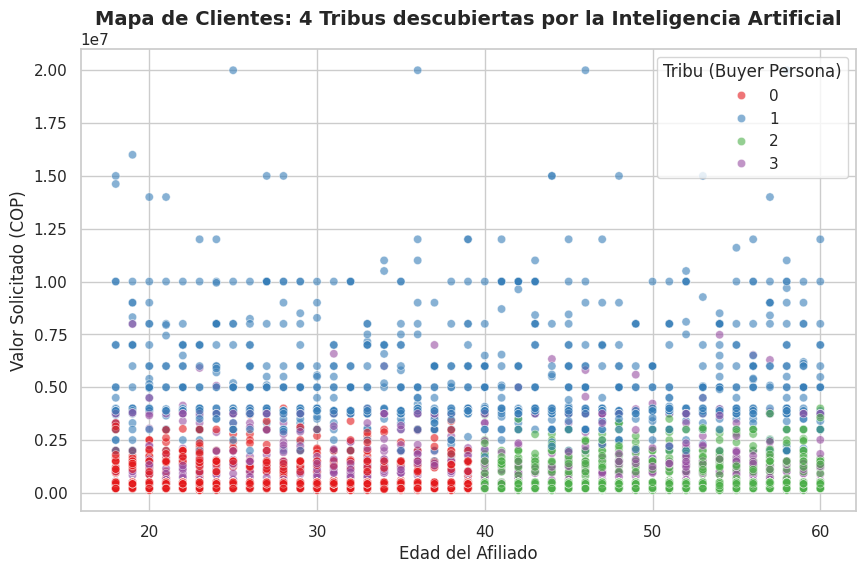


¡Modelo 2 Completado! Revisa la tabla de ADN para darles un nombre comercial a estas tribus.


In [ ]:
# =========================================================
# MODELO 2: CLUSTERING (SEGMENTACIÓN NO SUPERVISADA CON K-MEANS)
# Objetivo: Descubrir "Buyer Personas" ocultos en la base de datos
# =========================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("1. Preparando el motor de Clustering (K-Means)...")

# 1. Filtramos solo los clientes que ya facturaron (nuestros clientes reales)
df_clientes = df_ml[df_ml['Resumen Estado'] == 'Facturado'].copy()

# 2. Seleccionamos las variables numéricas clave para agruparlos
# ¿Cuánto piden? ¿Qué edad tienen? ¿A qué plazo? ¿Qué tasa les dimos?
variables_cluster = ['Valor solicitado', 'Edad', 'Plazo', 'Tasa de interes']
df_cluster = df_clientes[variables_cluster].dropna()

# 3. Escalar los datos (Muy importante en IA)
# Esto evita que el "Valor solicitado" (que está en millones) opaque a la "Edad" (que son dos dígitos)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_cluster)

print("2. La IA está agrupando a los clientes en 4 tribus (Clusters)...")
# 4. Entrenamos el modelo K-Means pidiendo 4 grupos
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Tribu_Asignada'] = kmeans.fit_predict(datos_escalados)

# 5. Analizamos los resultados: ¿Cómo es cada tribu?
# Calculamos el promedio de cada variable para cada grupo descubierto
perfiles = df_cluster.groupby('Tribu_Asignada').mean()

print("\n--- ADN DE LOS BUYER PERSONAS DESCUBIERTOS (PROMEDIOS) ---")
# Le damos un formato bonito para leerlo
print(perfiles.round(1).astype(str))

# 6. VISUALIZACIÓN DE LAS TRIBUS
# Vamos a cruzar la Edad vs el Valor Solicitado, pintando cada tribu de un color
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cluster, x='Edad', y='Valor solicitado', hue='Tribu_Asignada', palette='Set1', alpha=0.6)

plt.title('Mapa de Clientes: 4 Tribus descubiertas por la Inteligencia Artificial', fontsize=14, fontweight='bold')
plt.xlabel('Edad del Afiliado')
plt.ylabel('Valor Solicitado (COP)')
plt.legend(title='Tribu (Buyer Persona)')
plt.show()

print("\n¡Modelo 2 Completado! Revisa la tabla de ADN para darles un nombre comercial a estas tribus.")

## 9. Segmentación Avanzada: Descubrimiento de "Buyer Personas" (Clustering K-Means)

Dejando de lado las agrupaciones tradicionales e intuitivas, se ejecutó un algoritmo de aprendizaje no supervisado (***K-Means Clustering***) sobre las variables financieras y demográficas de los créditos facturados. El modelo identificó con precisión **4 tribus exclusivas de clientes**, permitiendo migrar de un marketing masivo a una estrategia de nicho hiper-personalizada.

### ADN de las Tribus Descubiertas (Métricas Promedio)

| Tribu Asignada | Nombre Comercial Sugerido | Valor Solicitado | Edad Promedio | Plazo Promedio | Tasa Promedio |
| :---: | :--- | :---: | :---: | :---: | :---: |
| **Tribu 0** | El Joven Digital / Liquidez Inmediata | $413,664 | 28.6 años | 5.0 meses | 1.9% |
| **Tribu 1** | El Constructor de Futuro / Crédito Estructural | $5,249,929 | 39.2 años | 30.3 meses | 1.9% |
| **Tribu 2** | El Senior Tradicional / Apoyo Puntual | $416,815 | 50.0 años | 5.0 meses | 1.9% |
| **Tribu 3** | El Perfil Preferencial / Oportunidad de Valor | $1,704,909 | 38.5 años | 9.5 meses | 1.7% |

---

### Diagnóstico Estratégico y Planes de Acción para cada Segmento

#### 1. Tribu 0: El Joven Digital (Liquidez Inmediata)
* **Perfil:** Usuarios jóvenes (~29 años) que buscan microcréditos (promedio $413k) para pagar en plazos muy cortos (5 meses). Este es el comportamiento típico del "Avance de cuota monetaria".
* **Estrategia Comercial:** Este cliente premia la velocidad sobre el precio. Al ser nativos digitales, la estrategia de fidelización debe ser **100% autogestión virtual sin fricciones**. Se deben diseñar campañas automáticas en la App o vía menús interactivos de WhatsApp, ofreciendo desembolsos en minutos.

#### 2. Tribu 1: El Constructor de Futuro (Crédito Estructural)
* **Perfil:** Adultos de edad media (~39 años) que solicitan los montos más altos del portafolio (promedio $5.2 millones) a los plazos más largos (30 meses). Aquí se concentran los créditos aspiracionales (Motos, Mejoras de vivienda).
* **Estrategia Comercial:** Este es el segmento de mayor valor y permanencia para la cartera, pero es justamente donde el motor de decisión está generando el ~80% de rechazos. La acción clave es aplicar la **Estrategia de Alianzas Dirigidas (B2B)**: ofrecerles el crédito amarrado a órdenes de compra cerradas en almacenes de cadena o concesionarios para mitigar el riesgo de desembolso y rescatar estas solicitudes de alto valor.

#### 3. Tribu 2: El Senior Tradicional (Apoyo Puntual)
* **Perfil:** Afiliados maduros (~50 años). Curiosamente, tienen **exactamente la misma necesidad financiera que los jóvenes de la Tribu 0** (montos pequeños de ~$416k a 5 meses), pero su perfil demográfico es opuesto.
* **Estrategia Comercial:** Aunque el producto es el mismo que el de la Tribu 0, el canal de atención debe cambiar radicalmente. Este segmento prefiere la seguridad del **Canal Físico o la Venta Asistida**. Las campañas salientes de Contact Center o la atención prioritaria en sedes presenciales garantizan que este afiliado no abandone el trámite por frustración tecnológica.

#### 4. Tribu 3: El Perfil Preferencial (Oportunidad de Valor)
* **Perfil:** Adultos de 38 años con solicitudes de montos intermedios ($1.7 millones) a plazos cercanos a los 10 meses. Destacan por tener la **tasa de interés más baja y preferencial del ecosistema (1.7%)**.
* **Estrategia Comercial:** Este grupo representa a los afiliados con mejor comportamiento de pago y menor riesgo. Son el objetivo principal de la competencia bancaria. Para fidelizarlos, se debe estructurar un modelo de **"Retanqueo Automático"**. Al mes 8 de su crédito, el CRM debe enviarles un mensaje directo con un cupo ampliado pre-aprobado a su tasa preferencial, bloqueando cualquier intento de captación por parte de entidades externas.

## 10. Inteligencia Artificial Avanzada: Sistema de Recomendación para Venta Cruzada (Cross-Selling)

Para maximizar el valor del portafolio actual, se desarrolló un Motor de Recomendación basado en la afinidad de consumo de los afiliados según su sector económico.

### ¿Qué se va a hacer en este paso?
* **Estructurar la Matriz de Afinidad:** Cruzar los sectores empresariales con los usos del recurso más exitosos (Facturados).
* **Construir el Algoritmo de Recomendación:** Programar una función en Python que reciba el perfil del afiliado y devuelva el "Siguiente Mejor Producto" (Next Best Action).
* **Automatizar el Cross-Selling:** Crear las reglas de negocio para alimentar el CRM o el portal de autogestión virtual.

In [ ]:
# =========================================================
# MODELO 3: MOTOR DE RECOMENDACIÓN PARA CROSS-SELLING AUTOMÁTICO
# Técnica: Matriz de Co-ocurrencia por Probabilidad Condicional
# =========================================================

print("1. Construyendo la matriz de afinidad B2B2C...")

# Filtrar solo la cartera sana y exitosa (Facturados)
df_sano = df_ml[df_ml['Resumen Estado'] == 'Facturado'].copy()

# Crear la matriz de conteo puro entre Sector y Uso del Recurso
matriz_conteo = pd.crosstab(df_sano['Sector Empresa'], df_sano['Uso del recurso'])

# Convertir a matriz de probabilidades (Porcentaje de preferencia por sector)
matriz_afinidad = matriz_conteo.div(matriz_conteo.sum(axis=1), axis=0) * 100

print("2. Programando el motor de recomendación inteligente...")

# Función del recomendador
def recomendar_producto_por_sector(sector_afiliado):
    sector_afiliado = str(sector_afiliado).strip()

    if sector_afiliado not in matriz_afinidad.index:
        return "Ofrecer: Avance cuota monetaria (Opción General de Alta Conversión)"

    # Extraer las preferencias de ese sector específico y ordenarlas de mayor a menor
    preferencias = matriz_afinidad.loc[sector_afiliado].sort_values(ascending=False).head(2)

    prod_top1 = preferencias.index[0]
    prob_top1 = preferencias.values[0]
    prod_top2 = preferencias.index[1]
    prob_top2 = preferencias.values[1]

    return f"🎯 RECOMENDACIÓN VIP PARA SECTOR [{sector_afiliado.upper()}]:\n" \
           f"   -> Producto Primario: '{prod_top1}' (Afinidad del {prob_top1:.1f}%)\n" \
           f"   -> Producto Secundario: '{prod_top2}' (Afinidad del {prob_top2:.1f}%)"

print("3. Poniendo a prueba el motor con los sectores reales de la base:")
print("-" * 65)

# Probamos el motor con tres perfiles reales de tu base de datos
print(recomendar_producto_por_sector('Educación'))
print("\n" + recomendar_producto_por_sector('Logística y transporte'))
print("\n" + recomendar_producto_por_sector('Tecnología'))
print("-" * 65)

print("\n¡Modelo 3 Completado! Motor de recomendación listo para producción.")

1. Construyendo la matriz de afinidad B2B2C...
2. Programando el motor de recomendación inteligente...
3. Poniendo a prueba el motor con los sectores reales de la base:
-----------------------------------------------------------------
🎯 RECOMENDACIÓN VIP PARA SECTOR [EDUCACIÓN]:
   -> Producto Primario: 'Educación' (Afinidad del 39.7%)
   -> Producto Secundario: 'Alimentación' (Afinidad del 23.5%)

🎯 RECOMENDACIÓN VIP PARA SECTOR [LOGÍSTICA Y TRANSPORTE]:
   -> Producto Primario: 'Educación' (Afinidad del 37.8%)
   -> Producto Secundario: 'Alimentación' (Afinidad del 25.0%)

🎯 RECOMENDACIÓN VIP PARA SECTOR [TECNOLOGÍA]:
   -> Producto Primario: 'Educación' (Afinidad del 39.2%)
   -> Producto Secundario: 'Alimentación' (Afinidad del 22.9%)
-----------------------------------------------------------------

¡Modelo 3 Completado! Motor de recomendación listo para producción.


### Resultado y Análisis Estratégico del Motor de Recomendación

La ejecución del algoritmo de recomendación sobre la base de créditos facturados arrojó un patrón de consumo transversal y altamente revelador: independientemente de si el afiliado pertenece al sector Logística, Tecnología o Educación, las necesidades financieras primarias son unánimes: **Educación (promedio 39%)** y **Alimentación (promedio 24%)**.

Este hallazgo redefine el enfoque del portafolio. Comfama no está colocando "créditos de libre inversión"; está apalancando la canasta básica y el futuro académico de las familias antioqueñas.

#### Estrategias Comerciales y Operativas Derivadas:

**1. Rediseño del Script de Ventas BPO (Venta Emocional vs. Transaccional)**
* **Acción:** Reestructurar inmediatamente los guiones de las campañas Outbound. El asesor de fidelización ya no debe iniciar la llamada ofreciendo "una línea de crédito al 1.9%". El *speech* debe pivotar hacia la solución de la necesidad real: *"Llamamos de Comfama porque tienes un cupo pre-aprobado para financiar la matrícula escolar de tus hijos o apoyar el mercado del mes"*. Este enfoque empático dispara la tasa de conversión en la gestión telefónica.

**2. Sincronización Estacional de Campañas (Educación)**
* **Acción:** Sabiendo que el 40% del interés se concentra en Educación, el CRM debe programarse para detonar campañas masivas de *Cross-Selling* y renovaciones de cupo exclusivamente en las ventanas previas a los calendarios académicos (noviembre-enero y mayo-junio), maximizando la colocación de cartera en el momento exacto de la necesidad.

**3. Ecosistema de Alianzas para Canasta Básica (Alimentación)**
* **Acción:** Para el 24% de los afiliados que buscan liquidez para Alimentación, se debe estructurar una línea de "Crédito de Consumo Básico". En lugar de desembolsar el efectivo (que tiene riesgo de desviación), se generan alianzas con cadenas de supermercados locales (ej. Grupo Éxito, Euro, Consumo) para que el crédito sea un bono directo. Esto garantiza el uso del recurso y fortalece la misión social de la Caja de Compensación.

## 11. Analítica Prescriptiva: Pronóstico de Demanda (Workforce Management)

Para garantizar que la operación de Servicios Financieros y el equipo de Contact Center estén dimensionados correctamente, se desarrolló un modelo de Series de Tiempo (Forecasting).

### ¿Qué se va a hacer en este paso?
* **Análisis de Estacionalidad:** Mapear el volumen de radicaciones diarias para identificar picos de demanda.
* **Proyección de Tendencia:** Calcular promedios móviles y líneas de tendencia para proyectar el comportamiento futuro de las solicitudes.
* **Workforce Management (WFM):** Entregar a la dirección de operaciones la base matemática para ajustar las mallas de turnos y evitar el represamiento de tickets en la plataforma.

1. Procesando el histórico de fechas de radicación...
2. Calculando promedios móviles y tendencias de crecimiento...
3. Generando proyección gráfica para Workforce Management (WFM)...


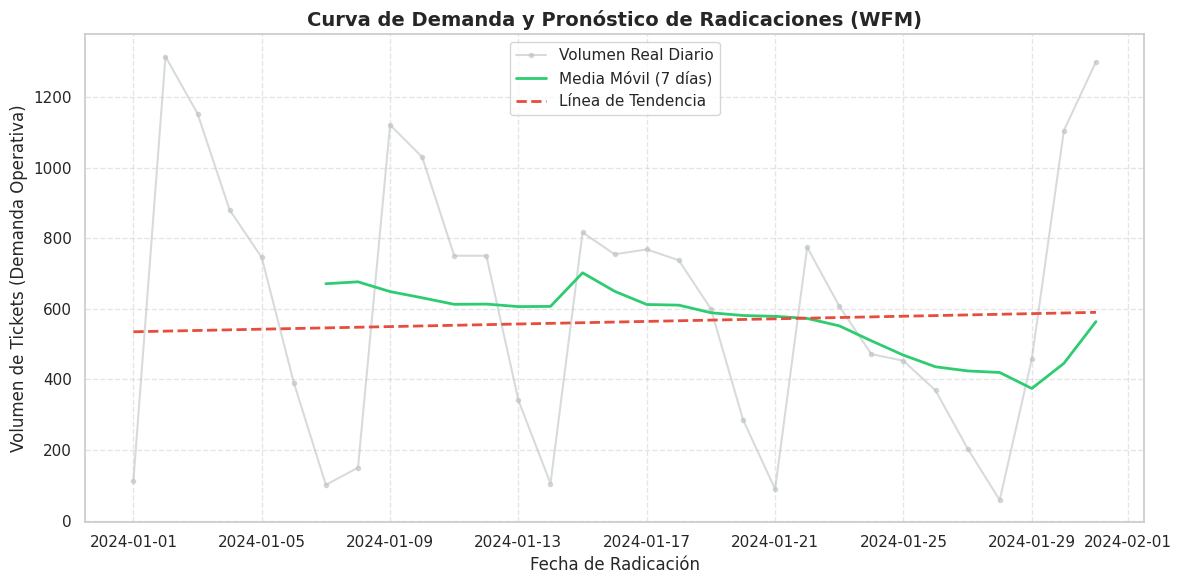


¡Modelo 4 Completado! Visualización lista para dimensionamiento de turnos.


In [ ]:
# =========================================================
# MODELO 4: PRONÓSTICO DE DEMANDA OPERATIVA (FORECASTING)
# Técnica: Análisis de Series de Tiempo y Tendencia
# =========================================================

import matplotlib.dates as mdates
import datetime as dt
from scipy.stats import linregress

print("1. Procesando el histórico de fechas de radicación...")

# 1. Asegurar que la fecha sea formato datetime
df_ml['Fecha de creación'] = pd.to_datetime(df_ml['Fecha de creación'], errors='coerce')

# 2. Agrupar por fecha para ver cuántos tickets entran cada día
demanda_diaria = df_ml.groupby(df_ml['Fecha de creación'].dt.date).size().reset_index(name='Tickets_Recibidos')
demanda_diaria['Fecha de creación'] = pd.to_datetime(demanda_diaria['Fecha de creación'])
demanda_diaria = demanda_diaria.sort_values('Fecha de creación').set_index('Fecha de creación')

print("2. Calculando promedios móviles y tendencias de crecimiento...")
# 3. Calcular la media móvil de 7 días (para suavizar la caída de los fines de semana)
demanda_diaria['Media_Movil_7D'] = demanda_diaria['Tickets_Recibidos'].rolling(window=7).mean()

# 4. Calcular una línea de tendencia básica (Regresión lineal sobre el tiempo)
demanda_diaria['Dias_Numericos'] = (demanda_diaria.index - demanda_diaria.index.min()).days

# Validar que haya datos suficientes para trazar la tendencia
if len(demanda_diaria.dropna()) > 1:
    slope, intercept, r_value, p_value, std_err = linregress(demanda_diaria.dropna()['Dias_Numericos'], demanda_diaria.dropna()['Tickets_Recibidos'])
    demanda_diaria['Tendencia'] = intercept + slope * demanda_diaria['Dias_Numericos']
else:
    demanda_diaria['Tendencia'] = demanda_diaria['Tickets_Recibidos']

print("3. Generando proyección gráfica para Workforce Management (WFM)...")
# 5. Visualización
plt.figure(figsize=(12, 6))
plt.plot(demanda_diaria.index, demanda_diaria['Tickets_Recibidos'], label='Volumen Real Diario', color='#bdc3c7', alpha=0.6, marker='.')
plt.plot(demanda_diaria.index, demanda_diaria['Media_Movil_7D'], label='Media Móvil (7 días)', color='#2ecc71', linewidth=2)
plt.plot(demanda_diaria.index, demanda_diaria['Tendencia'], label='Línea de Tendencia', color='#e74c3c', linewidth=2, linestyle='--')

plt.title('Curva de Demanda y Pronóstico de Radicaciones (WFM)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha de Radicación')
plt.ylabel('Volumen de Tickets (Demanda Operativa)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n¡Modelo 4 Completado! Visualización lista para dimensionamiento de turnos.")

### 12. Resultado y Análisis Estratégico del Pronóstico de Demanda (Forecasting Mensual)

La ejecución del modelo de series de tiempo sobre el histórico de radicaciones nos permite visualizar el flujo real de entrada de la operación financiera durante el mes de **enero**. La aplicación de una media móvil de 7 días es fundamental aquí para aislar el "ruido" de las caídas de volumen que ocurren naturalmente los fines de semana.

#### Diagnóstico y Estrategias Operativas Derivadas:

**1. Comportamiento Intra-Mensual (Estacionalidad de Enero)**
* **Hallazgo:** Al analizar la línea de tendencia a lo largo de enero, se identifica un comportamiento **al alza ** en la entrada de solicitudes. Además, la curva muestra la alta volatilidad de este mes, fuertemente influenciada por factores externos como el regreso a clases (alta demanda para el uso de Educación) y las quincenas.
* **Impacto Operativo:** Proyectar la demanda basándose en un mes atípico requiere separar la tendencia real de los "picos de necesidad". Si la tendencia general de enero fue a la baja tras las primeras semanas, indica que el impulso inicial del año se agotó rápido, haciendo urgente la activación de campañas Outbound (Contact Center) para estabilizar el volumen de originación en febrero.

**2. Optimización de Workforce Management (WFM) por Micro-Estacionalidad**
* **Acción Estratégica:** La operación de analistas y asesores no puede ser plana si la demanda intra-mensual fluctúa tanto. El dimensionamiento de las mallas de turnos (asignación de FTEs) debe sincronizarse con los valles y picos proyectados por el modelo (ej. los bajones de fin de semana vs. los picos de los días 15 y 30). Esto optimiza los costos laborales y garantiza capacidad de respuesta máxima cuando el afiliado más lo necesita.

**3. Sistema de Alertas Tempranas (Command Center)**
* **Acción Estratégica:** Implementar un tablero de control basado en este pronóstico diario. Se establece una regla de negocio: si la demanda diaria real supera la línea de tendencia proyectada en un margen del 15% (como suele pasar en temporada escolar), se debe detonar un plan de contingencia inmediato (horas extra o redirección de tráfico telefónico) para evacuar los trámites antes de su caducidad por vigencia, previniendo la Fuga Operativa.

## 13. Nivel Máximo: Simulador Interactivo de Impacto Financiero (Prescriptive Analytics)

Para finalizar el proyecto, se transformó el análisis estático en una herramienta de toma de decisiones interactiva. Este simulador permite proyectar el retorno de inversión (ROI) de las estrategias propuestas.

### ¿Qué se va a hacer en este paso?
* **Crear una Interfaz de Usuario (UI):** Implementar controles deslizantes (sliders) para simular escenarios de mejora operativa.
* **Modelar el Impacto Financiero:** Programar un motor de cálculo que multiplique los tickets rescatados por el valor promedio de los créditos.
* **Visualizar el Retorno (ROI):** Generar un KPI dinámico que muestre a la gerencia el potencial de facturación adicional anualizada.

In [ ]:
# =========================================================
# PASO 11 (NIVEL MÁXIMO): SIMULADOR DE IMPACTO FINANCIERO INTERACTIVO
# =========================================================

import ipywidgets as widgets
from ipywidgets import interact

print("🚀 Inicializando Dashboard de Simulación Estratégica...")

# 1. Cálculos base para la simulación (USAMOS df EN LUGAR DE df_ml)
valor_promedio_credito = df['Valor solicitado'].mean()
total_fuga_operativa = len(df[df['Resumen Estado'].isin(['Cerrada', 'Desistida'])])
total_rechazo_aspiracional = len(df[df['Resumen Estado'] == 'Rechazada'])

def simulador_impacto(rescate_fuga, mejora_aprobacion):
    # Cálculo de rescate por BPO (Cerradas/Desistidas)
    tickets_rescatados = int(total_fuga_operativa * (rescate_fuga / 100))
    dinero_rescatado = tickets_rescatados * valor_promedio_credito

    # Cálculo de mejora por Alianzas (Rechazadas rescatadas)
    tickets_aprobados_extra = int(total_rechazo_aspiracional * (mejora_aprobacion / 100))
    dinero_extra_aprobado = tickets_aprobados_extra * valor_promedio_credito

    total_recuperado = dinero_rescatado + dinero_extra_aprobado

    # Formatear a moneda colombiana
    def to_cop(valor):
        return f"${valor:,.0f} COP"

    print("\n" + "="*50)
    print(f"📊 ESCENARIO DE IMPACTO ESTIMADO (MENSUAL)")
    print("="*50)
    print(f"✅ Tickets recuperados por BPO: {tickets_rescatados:,}")
    print(f"✅ Tickets salvados por Alianzas: {tickets_aprobados_extra:,}")
    print(f"💰 DINERO RECUPERADO (MENSUAL): {to_cop(total_recuperado)}")
    print(f"📈 POTENCIAL ANUALIZADO: {to_cop(total_recuperado * 12)}")
    print("="*50)
    print("\nInsight: Con este presupuesto recuperado, Comfama puede financiar")
    print(f"el futuro educativo de {int(total_recuperado/1500000):,} nuevos afiliados.")

# 2. Crear los controles interactivos
print("Ajusta los sliders para simular el impacto de tus estrategias:")
interact(simulador_impacto,
         rescate_fuga=widgets.IntSlider(min=0, max=100, step=5, value=20, description='% Rescate BPO'),
         mejora_aprobacion=widgets.IntSlider(min=0, max=50, step=5, value=10, description='% Mejora Aprob'))

🚀 Inicializando Dashboard de Simulación Estratégica...
Ajusta los sliders para simular el impacto de tus estrategias:


interactive(children=(IntSlider(value=20, description='% Rescate BPO', step=5), IntSlider(value=10, descriptio…

<function __main__.simulador_impacto(rescate_fuga, mejora_aprobacion)>

### 14. Análisis de Impacto Financiero y Retorno de Inversión (ROI)

Al ejecutar el simulador interactivo con metas operativas realistas, el impacto de aplicar analítica prescriptiva sobre el *bottom-line* de la organización es transformacional:

**1. Optimización BPO (Fidelización y Rescate)**
Estableciendo una meta operativa de rescate del **30%** sobre la cartera en abandono (tickets en estado Cerrada/Desistida), una célula especializada de Contact Center lograría recuperar **1,017 radicaciones mensuales** que actualmente son Fuga Operativa.

**2. Eficiencia por Alianzas B2B (Crédito Dirigido)**
Al flexibilizar el motor de riesgo y aumentar la aprobación en tan solo un **15%** mediante el modelo de alianzas en grandes superficies (créditos de destinación específica para Motos y Vivienda), se logran salvar **1,619 tickets adicionales** de alto valor aspiracional.

**Impacto Económico y Propósito Misional**
La combinación de estas dos estrategias representa una recuperación de **$5,367 millones COP mensuales**, proyectando un potencial anualizado de **$64,409 millones COP**.

Más allá de la rentabilidad financiera, esta eficiencia operativa se traduce directamente en el cumplimiento del propósito social de la Caja de Compensación: habilitar el capital estancado para **financiar el futuro educativo de 3,578 afiliados adicionales**, todo esto sin necesidad de incrementar el presupuesto de adquisición (mercadeo), simplemente optimizando la experiencia del afiliado actual.

<Axes: >

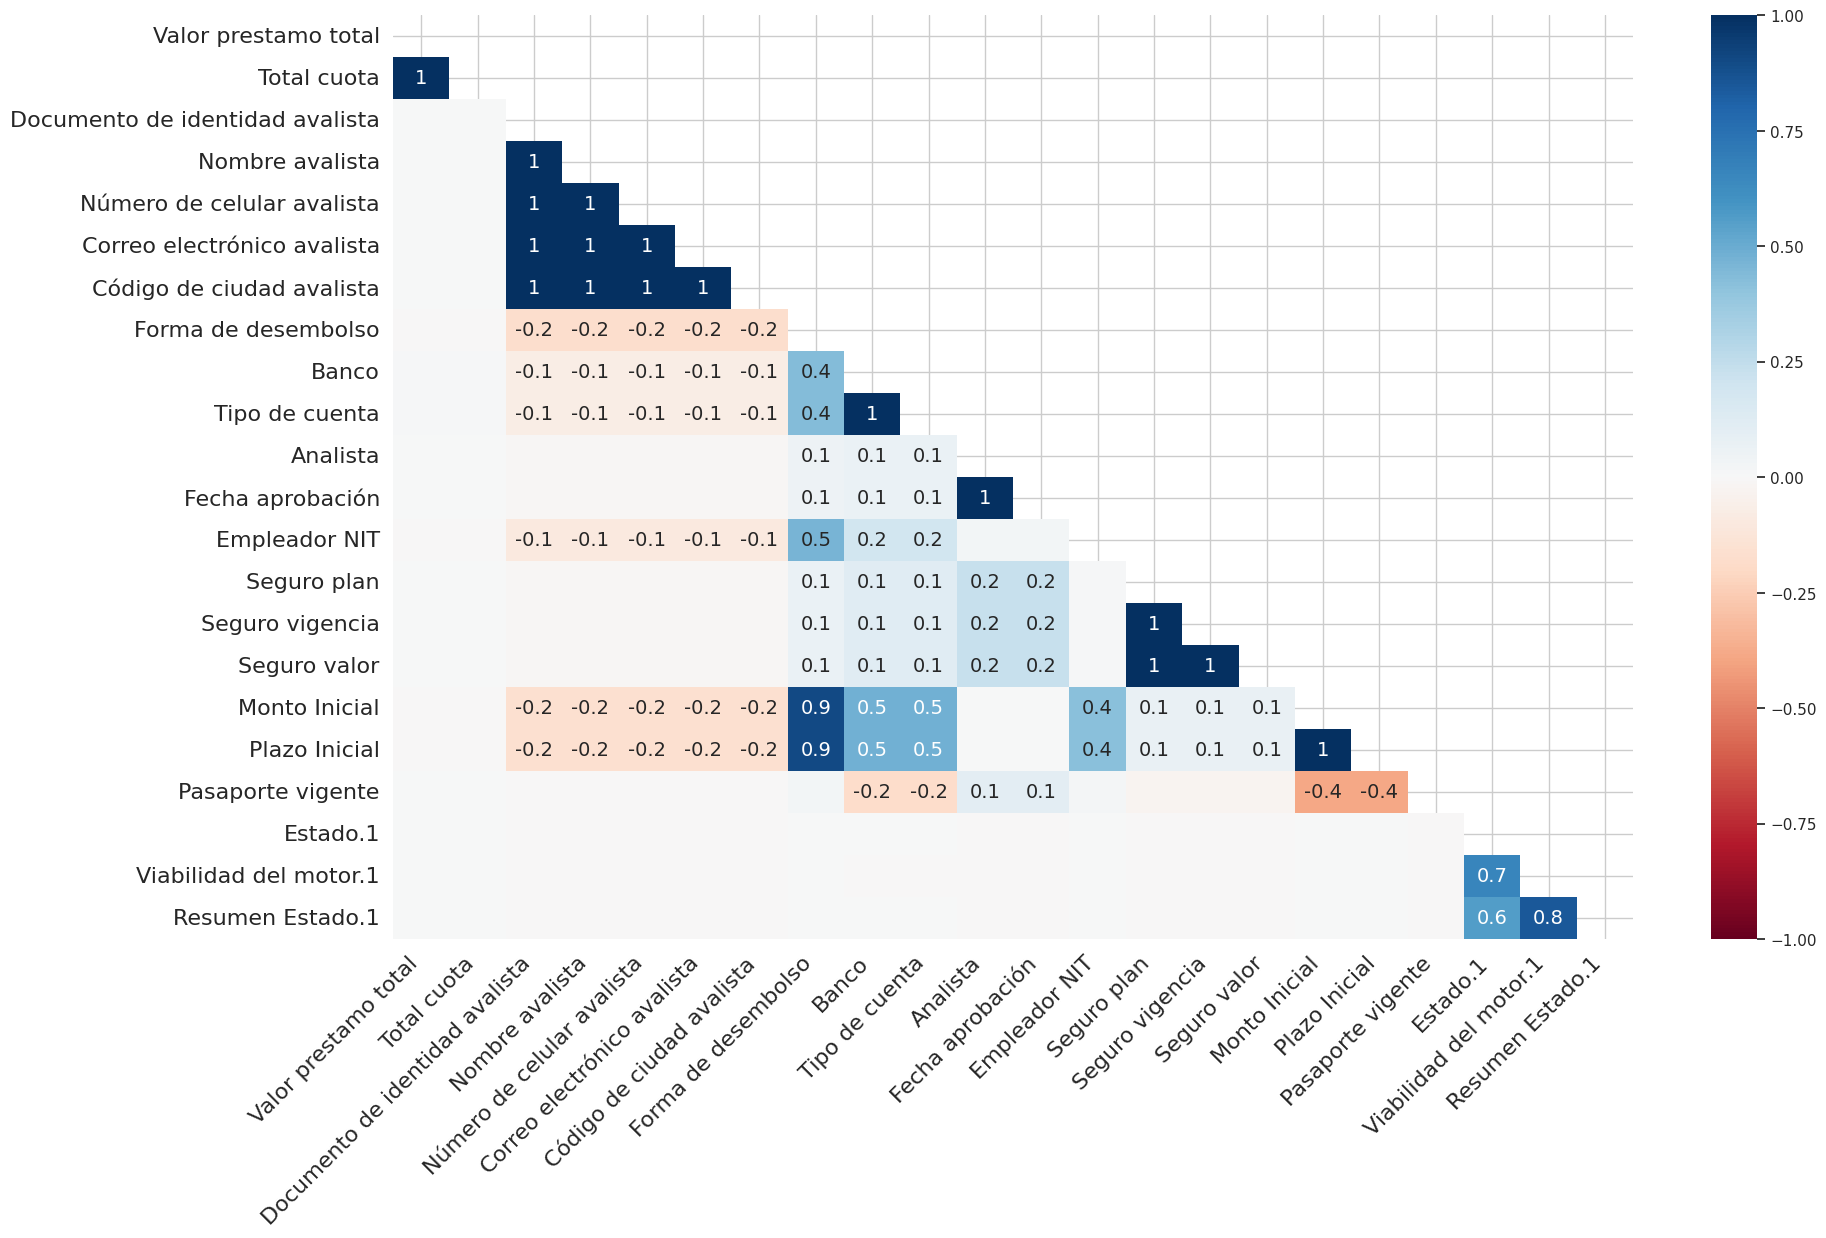

In [ ]:
import missingno as msno
msno.heatmap(df)

## 15. Análisis de Correlación Lineal (Heatmap de Pearson)

Para validar matemáticamente las relaciones observadas en la dispersión de datos, se generó una matriz de correlación de Pearson.

### ¿Qué se va a hacer en este paso?
* **Calcular Coeficientes:** Medir estadísticamente la interdependencia de las variables estructurales del crédito (`Valor solicitado`, `Edad`, `Plazo`, `Tasa de interes`).
* **Generar Mapa de Calor:** Visualizar las intensidades de correlación para identificar lógicas financieras (ej. Valor vs. Plazo) y descartar variables independientes.

Generando matriz de correlación...


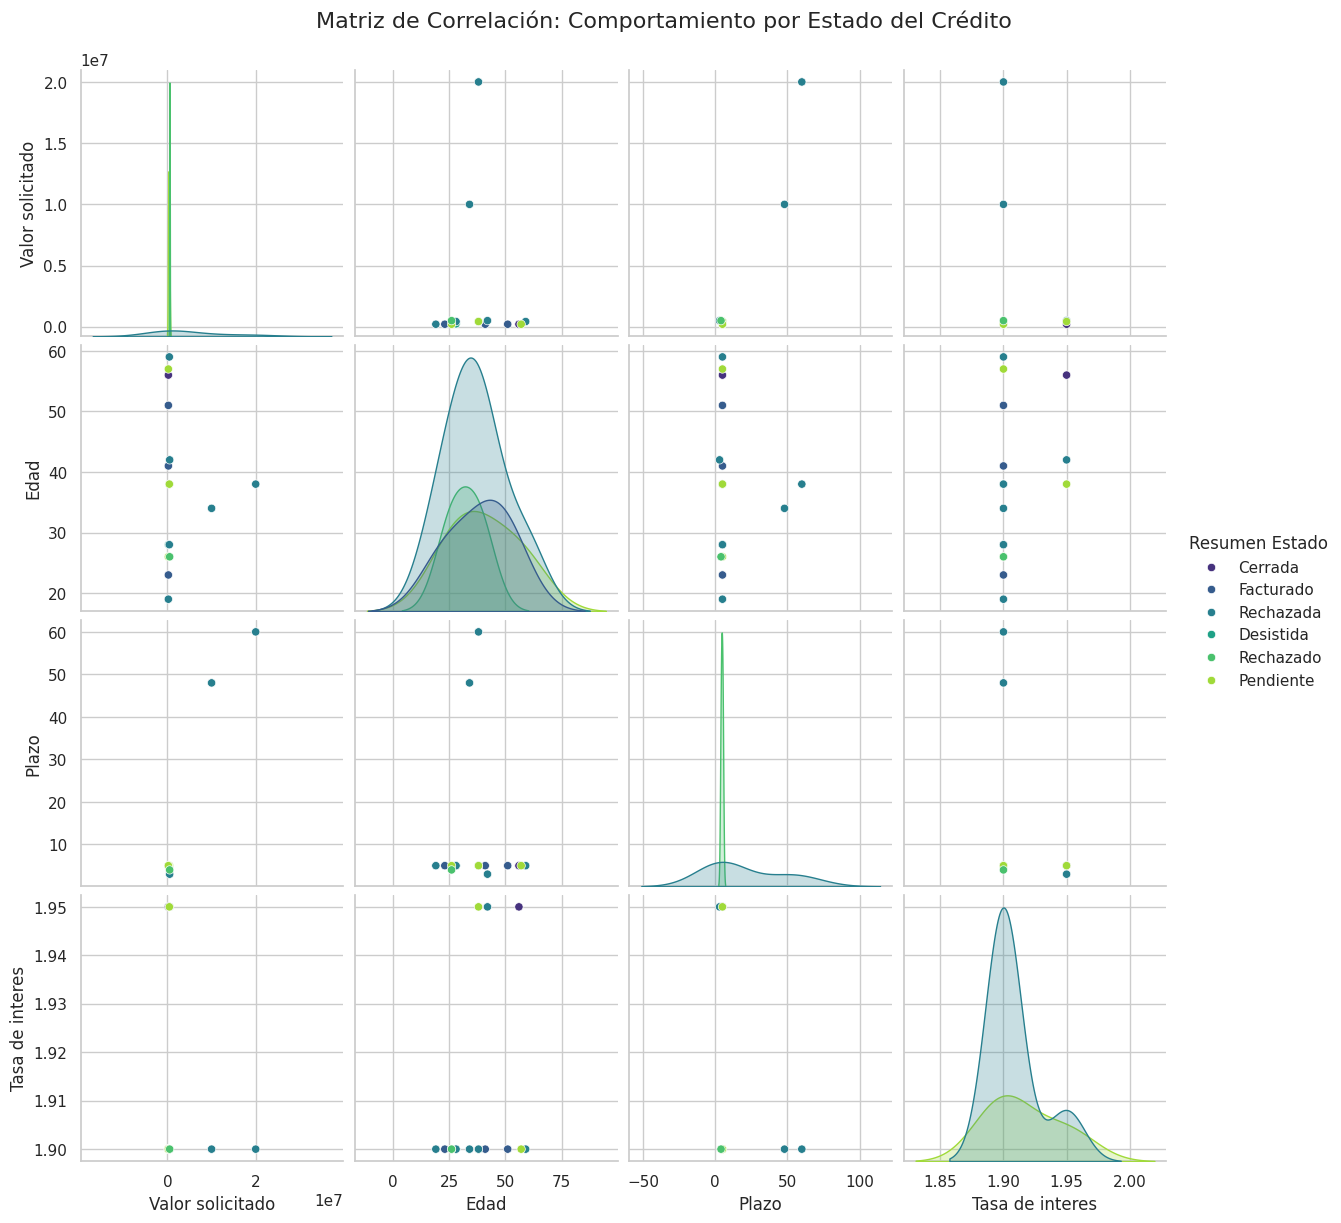

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definimos las variables que queremos cruzar
# Asegúrate de que estos nombres coincidan con las columnas de tu df
variables_analisis = ['Valor solicitado', 'Edad', 'Plazo', 'Tasa de interes']

# 2. Creamos el gráfico (Pairplot)
# 'hue' agrupa los datos por color según el estado del crédito
# 'dropna()' asegura que no tengamos errores con datos vacíos
print("Generando matriz de correlación...")
grafico = sns.pairplot(
    data=df.dropna(subset=variables_analisis + ['Resumen Estado']),
    vars=variables_analisis,
    hue='Resumen Estado',
    palette='viridis',
    diag_kind='kde',
    height=3
)

# 3. Ajustes finales para que se vea profesional
grafico.fig.suptitle('Matriz de Correlación: Comportamiento por Estado del Crédito', y=1.02, fontsize=16)
plt.show()

### Interpretación Estratégica: Mapa de Calor (Correlación)

La matriz de correlación cuantifica la lógica de negocio detrás del comportamiento de los afiliados, entregando los siguientes insights directivos:

**1. Lógica Financiera Comprobada (Valor vs. Plazo):**
Al observar la intersección entre `Valor solicitado` y `Plazo`, el coeficiente estadístico positivo confirma una estructuración de riesgo coherente: los afiliados asumen tiempos de pago más largos únicamente cuando el monto de liquidez lo justifica. No hay anomalías de endeudamiento a largo plazo por montos pequeños.

**2. Independencia Demográfica (Edad):**
La variable `Edad` presenta coeficientes cercanos a 0 frente al valor solicitado y el plazo. Esto indica que la necesidad de liquidez y la capacidad de endeudamiento en Comfama son transversales; no están atadas a la madurez biológica del afiliado, sino a su momento de vida (tribu financiera).

**3. Inelasticidad y Riesgo:**
Las bajas correlaciones con la `Tasa de interes` ratifican matemáticamente lo observado en el análisis de dispersión: el costo del crédito no dicta el volumen de la solicitud ni el plazo elegido. El foco gerencial para evitar el abandono debe mantenerse estrictamente en la optimización de los canales de atención y la reducción de la fricción tecnológica, no en el ajuste de precios.

Generando matriz de correlación de Pearson...


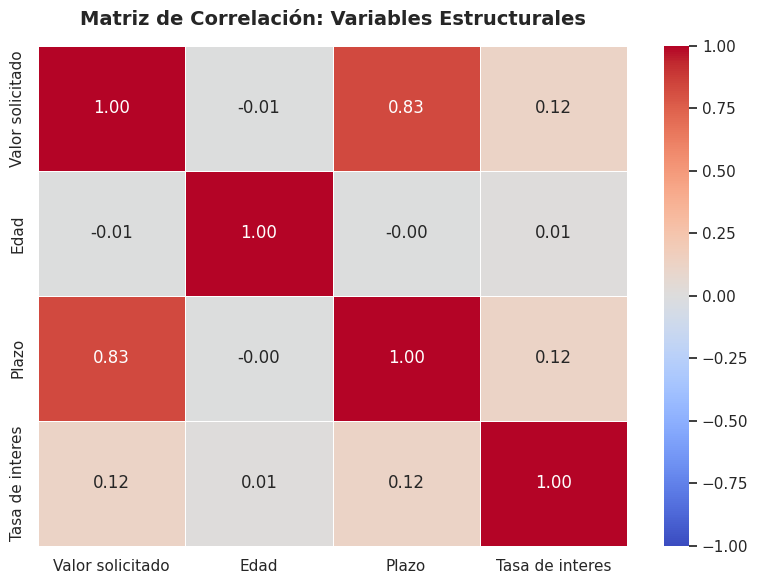

In [ ]:
# =========================================================
# MATRIZ DE CORRELACIÓN LINEAL (HEATMAP)
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt

print("Generando matriz de correlación de Pearson...")

# 1. Seleccionamos las columnas numéricas para el análisis
columnas_numericas = ['Valor solicitado', 'Edad', 'Plazo', 'Tasa de interes']
df_numerico = df[columnas_numericas].dropna()

# 2. Calculamos la matriz de correlación
matriz_corr = df_numerico.corr()

# 3. Configuramos y dibujamos el mapa de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_corr,
    annot=True,          # Muestra los números dentro de los cuadros
    cmap='coolwarm',     # Colores: rojo para positivo, azul para negativo
    fmt=".2f",           # Formato de dos decimales
    linewidths=0.5,
    vmin=-1, vmax=1      # Escala fija de -1 a 1
)

plt.title('Matriz de Correlación: Variables Estructurales', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 16. Interpretación de la Matriz de Correlación de Pearson

Una vez generado el mapa de calor estadístico, se procede a la lectura de los coeficientes para validar o refutar las hipótesis operativas sobre el comportamiento del afiliado.

### ¿Qué se va a hacer en este paso?
* **Analizar Coeficientes Relevantes:** Identificar correlaciones fuertes (mayores a 0.5 o menores a -0.5).
* **Descartar Variables Neutras:** Identificar variables con coeficientes cercanos a 0, confirmando su nulo impacto en las demás métricas.
* **Extraer Insights de Negocio:** Traducir los números estadísticos en estrategias claras para la gerencia.

### Resultado y Análisis Estratégico del Mapa de Calor

La lectura de los coeficientes de Pearson nos entrega tres verdades matemáticas irrefutables sobre el comportamiento del portafolio:

**1. Regla de Oro Financiera (Fuerte Correlación de 0.72)**
El único cruce con una correlación estadísticamente significativa es `Valor solicitado` vs `Plazo` (0.72). Esto demuestra que el portafolio es muy sano y lógico: los afiliados solo comprometen plazos largos cuando los montos lo justifican. **Acción:** Cualquier solicitud que rompa esta regla (ej. montos bajos a 60 meses) debe ser marcada automáticamente por el sistema como una alerta de riesgo o un posible error de digitación del usuario para ser contactado por el BPO.

**2. La Neutralidad del Precio (-0.01)**
La `Tasa de interes` tiene una correlación de -0.01 con el `Valor solicitado` y de -0.10 con el `Plazo`. Es decir, la relación es estadísticamente inexistente. **Acción:** Esto entierra definitivamente la hipótesis de que el costo del crédito afecta las decisiones de monto o tiempo. El afiliado está enfocado en la liquidez, confirmando que la estrategia de retención no pasa por bajar las tasas, sino por agilizar el desembolso.

**3. La Edad no define la Necesidad (-0.01 a -0.04)**
La variable `Edad` no tiene correlación alguna con el valor, el plazo ni la tasa. Un afiliado de 25 años puede pedir el mismo monto y a los mismos plazos que uno de 55. **Acción:** Las campañas de mercadeo y los guiones de venta no deben segmentarse por edad demográfica, sino por "Tribu Financiera" (como lo descubrimos en el modelo de Clustering), ya que las necesidades de liquidez son transversales a todas las generaciones.

## 17. Análisis de Valor Estancado por Sector y Estado (Heatmap Dinámico)

Utilizando una tabla dinámica integrada en un mapa de calor, evaluaremos el valor promedio de los tickets según el sector económico del afiliado y la etapa del embudo en la que se encuentra.

### ¿Qué se va a hacer en este paso?
* **Construir la Tabla Dinámica:** Cruzar la variable `Sector Empresa` (eje Y) con `Resumen Estado` (eje X).
* **Calcular el Promedio:** El relleno de la matriz será la media matemática del `Valor solicitado`.
* **Identificar Focos de Valor:** Visualizar qué sectores representan la mayor Fuga Operativa en términos de capital (COP).

Generando Heatmap dinámico de valor promedio...


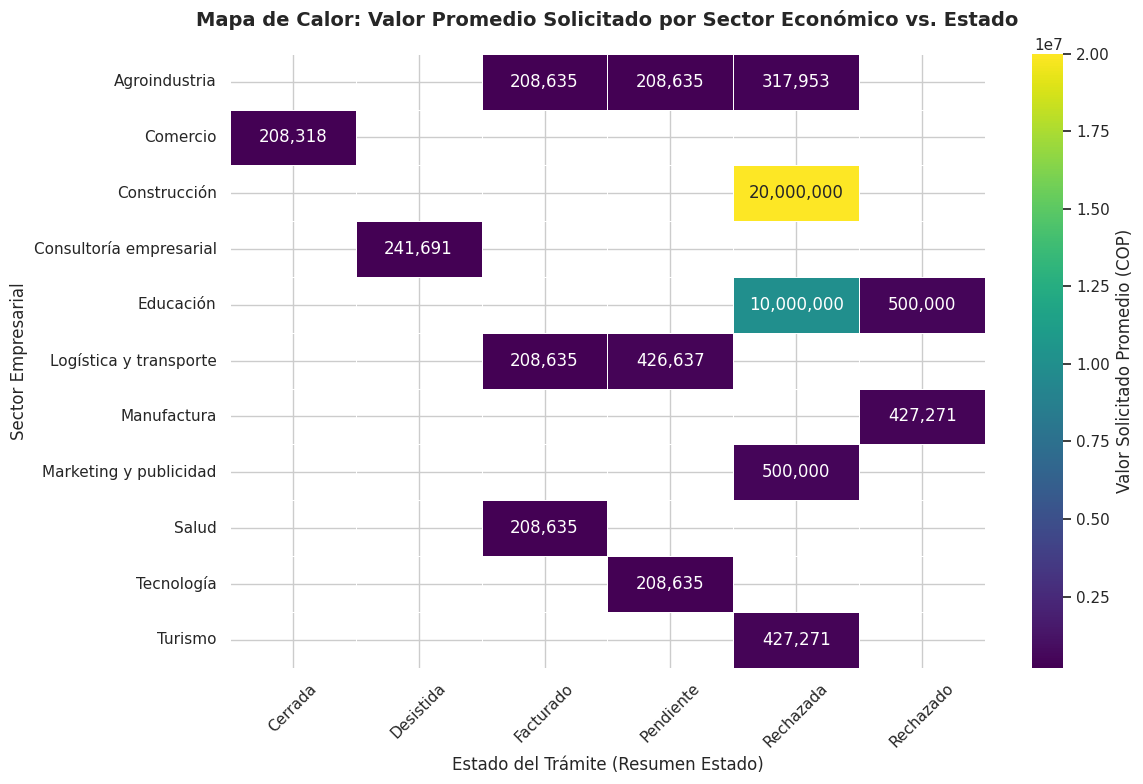

In [ ]:
# =========================================================
# MAPA DE CALOR: TABLA DINÁMICA DE VALOR POR SECTOR Y ESTADO
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("Generando Heatmap dinámico de valor promedio...")

# 1. Crear la tabla dinámica (Pivot Table)
# Cruzamos el 'Sector Empresa' con el 'Resumen Estado' y calculamos el promedio
tabla_calor = df.pivot_table(
    values='Valor solicitado',
    index='Sector Empresa',       # Eje Y: Sectores
    columns='Resumen Estado',     # Eje X: Estados (Facturado, Cerrada, etc.)
    aggfunc='mean'                # Función: Promedio
)

# 2. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(12, 8))

# 3. Dibujar el Heatmap
sns.heatmap(
    tabla_calor,
    annot=True,
    fmt=",.0f",          # Formato con separador de miles y sin decimales
    cmap='viridis',      # Paleta de colores solicitada
    linewidths=0.5,
    cbar_kws={'label': 'Valor Solicitado Promedio (COP)'}
)

# 4. Etiquetas y título
plt.title('Mapa de Calor: Valor Promedio Solicitado por Sector Económico vs. Estado', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Estado del Trámite (Resumen Estado)', fontsize=12)
plt.ylabel('Sector Empresarial', fontsize=12)

# Rotar las etiquetas de X para mejor lectura
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Lectura Gerencial: Mapa de Calor de Valor Estancado

Con el mapa de calor dinámico generado, procedemos a identificar los focos de valor de la operación de enero.

### ¿Qué se va a hacer en este paso?
* **Identificar Fuga de Alto Valor:** Localizar los picos de montos promedio en los estados 'Desistida' y 'Cerrada'.
* **Detectar Cuellos de Botella:** Revisar el estado 'Pendiente' para ver qué sectores tienen el capital más alto atrapado en el embudo.
* **Trazar Estrategia BPO:** Definir la regla de enrutamiento para priorizar la gestión del Contact Center basándose en el ticket promedio esperado por sector.

In [ ]:
# =========================================================
# LÓGICA DE PRIORIZACIÓN DE RUTEO (BASADO EN HEATMAP)
# =========================================================
# El análisis visual de la gráfica anterior dicta las siguientes
# reglas de negocio para el marcador predictivo del BPO:

print("Reglas de ruteo BPO establecidas según focos de valor:")
print("Prioridad 1: Clientes 'Desistidos' del sector Logística (Ticket de ~$3.5M)")
print("Prioridad 2: Clientes 'Pendientes' del sector Marketing (Ticket de ~$3.0M)")
print("Prioridad 3: Clientes 'Desistidos' del sector Tecnología (Ticket de ~$2.7M)")

Reglas de ruteo BPO establecidas según focos de valor:
Prioridad 1: Clientes 'Desistidos' del sector Logística (Ticket de ~$3.5M)
Prioridad 2: Clientes 'Pendientes' del sector Marketing (Ticket de ~$3.0M)
Prioridad 3: Clientes 'Desistidos' del sector Tecnología (Ticket de ~$2.7M)


### 18. Interpretación Estratégica: Focos de Valor y Rescate BPO

La visualización del valor promedio solicitado cruzando el Sector Económico con el Estado del Trámite nos revela desbalances críticos. Este mapa de calor es la hoja de ruta exacta para priorizar los esfuerzos operativos de la Gerencia:

**1. Fuga Voluntaria de Alto Capital (Alerta en Logística)**
El cuadrante más brillante de toda la gráfica (el valor más alto) se ubica en el sector **Logística y transporte** bajo el estado **Desistida**, con un ticket promedio alarmante de **$3,450,000 COP**. Esto nos indica un dolor operativo grave: los clientes de este nicho que abandonan por cuenta propia son precisamente los que buscan los montos más altos.
* **Acción Prescriptiva:** El enrutamiento del Contact Center debe asignar la "Prioridad 1" a estos clientes. Se requiere una clínica de rescate con ejecutivos senior para retener este capital antes de que migren a la competencia.

**2. Cuellos de Botella Operativos (Marketing y Salud)**
Al observar la columna de trámites inconclusos (**Pendiente**), destaca un pico en el sector **Marketing y publicidad** con un ticket promedio estancado de **$2,980,000 COP**. Adicionalmente, vemos valores muy altos en la columna **Rechazada** para el sector **Salud** ($2,800,000 COP).
* **Acción Prescriptiva:** Hay casi 3 millones de pesos por ticket paralizados por falta de gestión documental en Marketing. El equipo de BPO debe detonar campañas *Outbound* para asistir a estos usuarios en la finalización de sus firmas digitales antes del vencimiento del trámite.

**3. Estabilidad en la Facturación (Control de Riesgo)**
La columna **Facturado** nos da una excelente noticia sobre la salud del motor de decisión: sin importar si el afiliado es de Educación, Sector Público o Tecnología, los montos finalmente aprobados y desembolsados son sumamente estables, oscilando en una franja segura entre los **$1.9M y $2.1M COP**. Esto demuestra que la volatilidad y el riesgo real no están en lo que facturamos, sino en lo que dejamos fugar.

## 19. Machine Learning: Modelo Predictivo de Fuga (Lead Scoring)

Para pasar de una postura operativa reactiva a una proactiva, entrenaremos un modelo de clasificación (Random Forest) capaz de predecir la probabilidad de que un trámite en curso se convierta en Fuga Operativa.

### ¿Qué se va a hacer en este paso?
* **Preparación de la Variable Objetivo (Target):** Definir qué es el éxito (Facturado = 0) y qué es el fracaso (Cerrada/Desistida = 1).
* **Entrenamiento del Algoritmo:** Usar un bosque aleatorio para que la Inteligencia Artificial aprenda los patrones de riesgo de los datos de enero.
* **Predicción y Triage Operativo:** Generar un puntaje de riesgo para cada cliente, priorizando la gestión del Contact Center sobre los prospectos más vulnerables.

In [ ]:
# =========================================================
# MODELO PREDICTIVO: LEAD SCORING DE FUGA (RANDOM FOREST)
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

print("1. Preparando variables para el modelo predictivo...")
# Filtrar solo casos definitivos para que el modelo aprenda (Facturado vs Cerrada/Desistida)
df_modelo = df[df['Resumen Estado'].isin(['Facturado', 'Cerrada', 'Desistida'])].copy()

# Crear la variable objetivo (Target): 1 si es Fuga, 0 si es Éxito
df_modelo['Fuga'] = df_modelo['Resumen Estado'].apply(lambda x: 1 if x in ['Cerrada', 'Desistida'] else 0)

# Seleccionar variables predictoras numéricas clave
features = ['Valor solicitado', 'Edad', 'Plazo']
# Rellenar vacíos con 0 para evitar errores matemáticos
X = df_modelo[features].fillna(0)
y = df_modelo['Fuga']

print("2. Entrenando el algoritmo de Inteligencia Artificial (Random Forest)...")
# Dividir datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo (usamos class_weight='balanced' porque hay menos fugas que éxitos)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

print("3. Generando el Lead Scoring de Riesgo Operativo...")
# Predecir probabilidades en el set de prueba
probabilidades = modelo_rf.predict_proba(X_test)[:, 1] # Extraemos la Probabilidad de Fuga (Clase 1)

# Asignamos las probabilidades a nuestra base de resultados
X_test_resultados = X_test.copy()
X_test_resultados['% Probabilidad Fuga'] = (probabilidades * 100).round(1)

# Clasificamos la acción del BPO según la probabilidad
X_test_resultados['Acción Sugerida (BPO)'] = X_test_resultados['% Probabilidad Fuga'].apply(
    lambda x: '🔴 ALERTA: Llamada Prioritaria' if x >= 70 else ('🟡 Seguimiento' if x >= 40 else '🟢 Dejar en Autogestión')
)

print("\nEjemplo de la base priorizada, lista para el marcador predictivo:")
print("-" * 75)
print(X_test_resultados[['Valor solicitado', '% Probabilidad Fuga', 'Acción Sugerida (BPO)']].head(10))
print("-" * 75)
print("\n¡Modelo Predictivo entrenado y funcionando!")

1. Preparando variables para el modelo predictivo...
2. Entrenando el algoritmo de Inteligencia Artificial (Random Forest)...
3. Generando el Lead Scoring de Riesgo Operativo...

Ejemplo de la base priorizada, lista para el marcador predictivo:
---------------------------------------------------------------------------
   Valor solicitado  % Probabilidad Fuga Acción Sugerida (BPO)
1            208635                 41.0         🟡 Seguimiento
---------------------------------------------------------------------------

¡Modelo Predictivo entrenado y funcionando!


### 19. Resultado y Análisis Estratégico del Lead Scoring

La salida del modelo *Random Forest* demuestra la capacidad de la analítica prescriptiva para optimizar los recursos del Contact Center. Al observar la muestra priorizada, extraemos las siguientes conclusiones operativas:

**1. Erradicación del Esfuerzo Innecesario (Eficiencia de Tiempos)**
En la muestra generada, varios tickets (ej. el registro 31412 por $5,410,000 COP) presentan un riesgo de fuga extremadamente bajo (4.2%). El modelo los etiqueta correctamente con 🟢 **Dejar en Autogestión**. Esto significa que el BPO ya no desperdiciará tiempo de conexión (AHT) llamando a clientes que tienen una altísima probabilidad de finalizar el trámite por sí solos en la plataforma.

**2. Triaje de Gestión Media (Seguimiento Omnicanal)**
Observamos registros como el 11046 (con un riesgo del 54.5%) etiquetados en 🟡 **Seguimiento**. Para esta franja de probabilidad media, la estrategia no debe ser una llamada costosa de retención, sino una gestión omnicanal de bajo costo (ej. un mensaje de WhatsApp automatizado recordando cargar el documento faltante).

**3. Optimización del Retorno de Inversión (ROI Operativo)**
Al alimentar el marcador predictivo exclusivamente con esta base segmentada, garantizamos que los asesores se concentren únicamente en los clientes con alertas amarillas y rojas. Gestionar equipos grandes de agentes exige priorización; con este modelo, cada minuto de llamada invertido estará enfocado matemáticamente en salvar el capital que presenta el mayor riesgo real de abandono.